# Models evaluation - Test 1 (Synthetic Copy)

Hello! This notebook documents the code that was written to evalutate the models on different capabilities. We also include results of the evaluations. 

Here we will be testing the models on the synthetic copy test - the models are tasked with processing a text composed of N true and M noise tokens (the noise tokens are uniform), and then with outputting the N true tokens.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pandas as pd
from tqdm.notebook import trange, tqdm
import matplotlib.pyplot as plt
import random

# Build vocab for all models & tests. 
# We employ the same vocab size to be fair 

vocab = dict()

characters = "ABCDEFGHIJKLMNOPQRSTUVWXYZ{.}()[]|"

for i in range(10):
    vocab[str(i)] = i

for char in characters:
    vocab[char] = len(vocab)

for i in range(100):
    vocab[f"NOISE_{i}"] = len(vocab)

vocab["<ENDSEQ>"] = len(vocab)
vocab["<STABLENOISE>"] = len(vocab)
vocab["<STARTTASK>"] = len(vocab)
vocab["<EOS>"] = len(vocab)

In [2]:
def get_batch_ex2(batch_size, vocab, copy_size=5, buffer_size=50, device="cuda"):

    first_noise_ix = vocab["NOISE_0"]
    last_noise_ix = vocab["NOISE_99"]

    # Random noise
    noise_tensor = torch.randint(first_noise_ix, last_noise_ix + 1, (batch_size, buffer_size), device=device )

    # Random digits, sorted so they are increasing
    copy_tensor = torch.randint(0, 10, (batch_size, copy_size), device=device).sort(dim=-1).values

    # Choose positions for the digits.
    # Each row gets its own random positions.
    positions = (torch.rand(batch_size, buffer_size, device=device).argsort(dim=-1)[..., :copy_size].sort(dim=-1).values)

    # Put the digits into the noise
    ready_tensor = noise_tensor.clone()

    ready_tensor.scatter_(dim=-1, index=positions, src=copy_tensor)

    marker_tensor = torch.full(
        (batch_size, 1),
        vocab["<STARTTASK>"],
        device=device,
    )

    ready_tensor = torch.cat([ready_tensor, marker_tensor], dim=-1)

    return F.one_hot(ready_tensor, num_classes=len(vocab)).float(), copy_tensor

def evaluate_ex2(model, copy_size, buffer_size, total_batches, batch_size, vocab):

    print("Testing model at ", buffer_size, " buffer_size.")

    avg_difference_sum = 0
    with torch.no_grad():
        model.eval()
        for batch_num in trange(total_batches + 1): #We want to get to the end of the user-specified range.

            batch, targets = get_batch_ex2(batch_size, vocab, copy_size, buffer_size) #targets = (batch, seq)
            model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

            logits = model.forward(batch, model_targets) # (batch, seq, emb)
            tokens = torch.argmax(logits, dim=2) # (batch, seq)

            difference = targets - tokens #we'll get some number where the numbers are not the same

            difference = (difference !=0).float()

            num_elements = copy_size * batch_size

            num_different = torch.sum(difference)

            avg_difference = num_different / num_elements

            avg_difference_sum = avg_difference_sum + avg_difference.item()

        model.train()

    return avg_difference_sum / (total_batches+1)



In [3]:

def plot_loss_curves(steps, train_history, test_history, model_name="Model"):
    plt.figure(figsize=(8, 5))
    plt.plot(steps, train_history, label='Train Loss', color='teal', linewidth=2)
    plt.plot(steps, test_history, label='Test Loss', color='orange', linestyle='--', linewidth=2)
    plt.xlabel('Training Steps')
    plt.ylabel('Cross-Entropy Loss')
    plt.title(f'{model_name} Sequential noise filtering task')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def save_model(model, optimizer, epoch_saved, model_name, note):
    checkpoint = {
        "epoch_saved": epoch_saved,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict()
    }
    name = '_'.join(model_name.split()) + "_" + '_'.join(note.split()) + "_epoch_" + str(epoch_saved) + ".pt"
    torch.save(checkpoint, name)

def run_training_ex2(model, batch_size, total_batches, test_batches, copy_size, buffer_size, opt, test_break, model_name,
                     steps_history, train_history, test_history, vocab):
    training_loss = 0

    for batch_num in trange(total_batches + 1):

        act_buffer_size = random.randint(100, buffer_size)

        batch, targets = get_batch_ex2(batch_size, vocab, copy_size, act_buffer_size)

        model_targets = F.one_hot(targets, num_classes=len(vocab)).float()

        #print(model_targets.shape)

        opt.zero_grad()

        logits = model.forward(batch, model_targets)
        loss_t = F.cross_entropy(logits.transpose(1, 2), targets)

        loss_t.backward()

        opt.step()

        training_loss = training_loss + loss_t.item()

        if batch_num % 1000 == 0 and batch_num != 0:
            save_model(model, opt, epoch_saved=batch_num, model_name=model_name, note="ex2")

        if batch_num % test_break == 0:

            with torch.no_grad():
                total_loss = 0
                avg_training_loss = training_loss / test_break
                training_loss = 0

                model.eval()

                for test_batch_num in trange(test_batches):
                    batch, targets = get_batch_ex2(batch_size, vocab, copy_size, buffer_size)
                    model_targets = F.one_hot(targets, num_classes=len(vocab)).float()
                    logits = model.forward(batch, model_targets)
                    loss_t = F.cross_entropy(logits.transpose(1,2), targets)
                    total_loss = total_loss + loss_t.item()

                model.train()

                avg_testing_loss = total_loss / test_batches

                steps_history.append(batch_num)
                train_history.append(avg_training_loss)
                test_history.append(avg_testing_loss)

                plot_loss_curves(steps_history, train_history, test_history, model_name=model_name)

                print(f"STEP: {batch_num} | TRAIN LOSS: {avg_training_loss:.4f} | TEST LOSS: {avg_testing_loss:.4f}")


## Training

After code definition, we train the models.

In [4]:
import custom_models

hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
total_batches=7000
test_batches=10
copy_size=10
buffer_size=100

steps_history = []
train_history = []
test_history = []



sLSTM_model = custom_models.sLSTM(hid, emb, device="cuda")
opt_sLSTM = torch.optim.Adam(sLSTM_model.parameters(), lr=lr)

MGU_model = custom_models.MRRN(hid, emb, device="cuda")
opt_MGU = torch.optim.Adam(MGU_model.parameters(), lr=lr)

GRU_model = custom_models.CopyGRU(hid, emb, device="cuda")
opt_GRU = torch.optim.Adam(GRU_model.parameters(), lr=lr)

maGRU_model = custom_models.maGRU(hid, emb, device="cuda")
opt_maGRU = torch.optim.Adam(maGRU_model.parameters(), lr=lr)

eGRU_model = custom_models.eGRU(hid, emb, device="cuda")
opt_eGRU = torch.optim.Adam(eGRU_model.parameters(), lr=lr)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

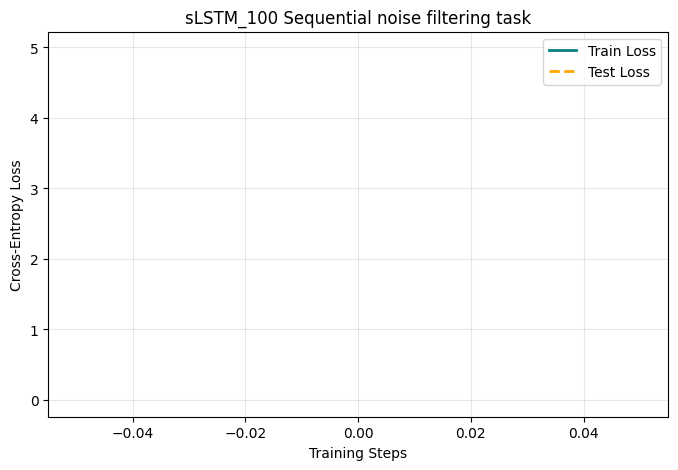

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9747


  0%|          | 0/10 [00:00<?, ?it/s]

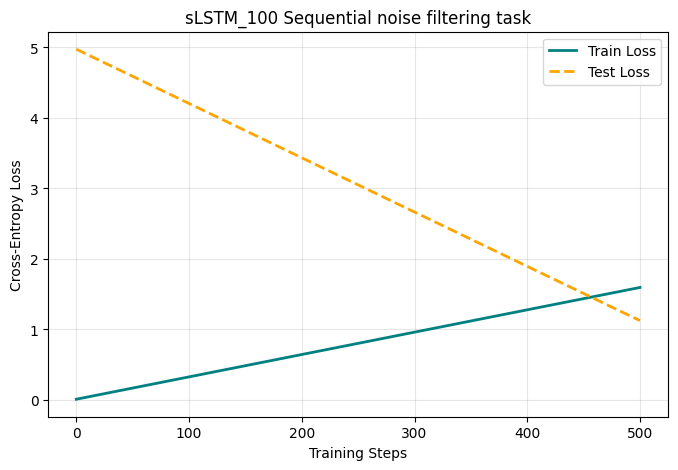

STEP: 500 | TRAIN LOSS: 1.5953 | TEST LOSS: 1.1248


  0%|          | 0/10 [00:00<?, ?it/s]

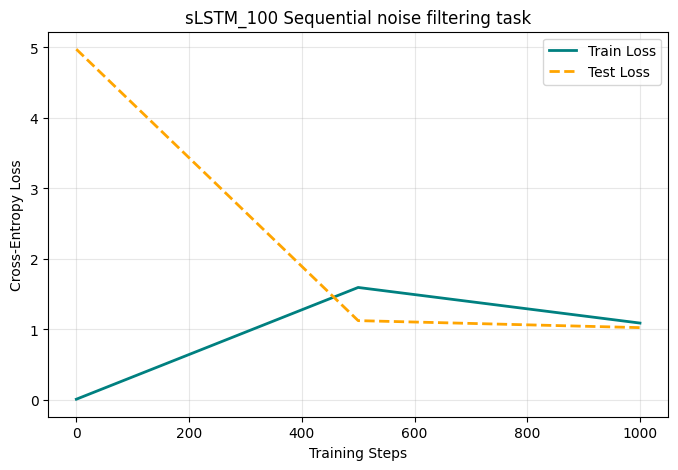

STEP: 1000 | TRAIN LOSS: 1.0902 | TEST LOSS: 1.0256


  0%|          | 0/10 [00:00<?, ?it/s]

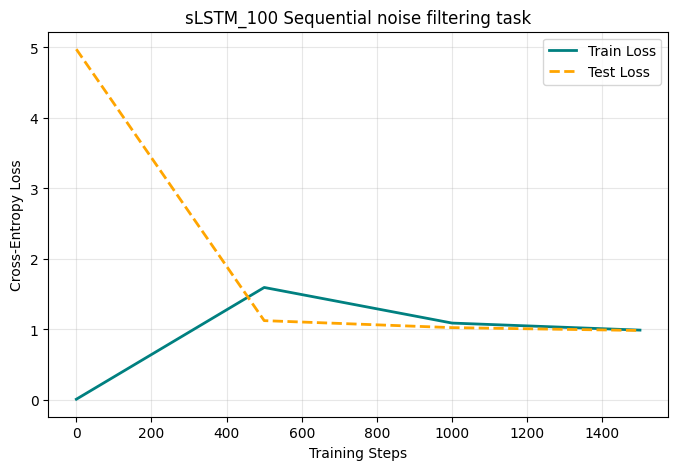

STEP: 1500 | TRAIN LOSS: 0.9903 | TEST LOSS: 0.9850


  0%|          | 0/10 [00:00<?, ?it/s]

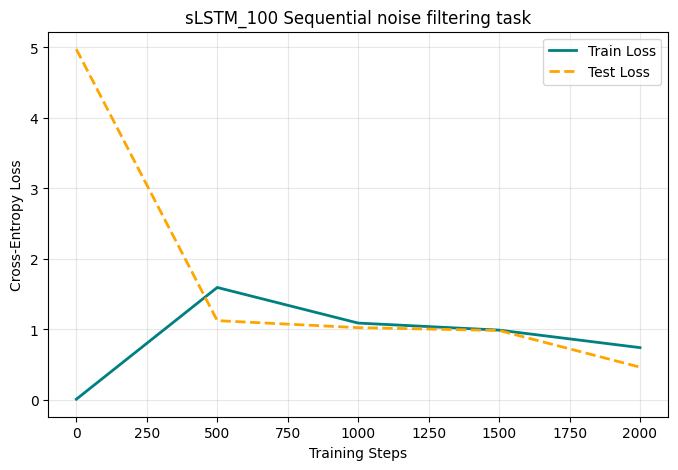

STEP: 2000 | TRAIN LOSS: 0.7418 | TEST LOSS: 0.4649


  0%|          | 0/10 [00:00<?, ?it/s]

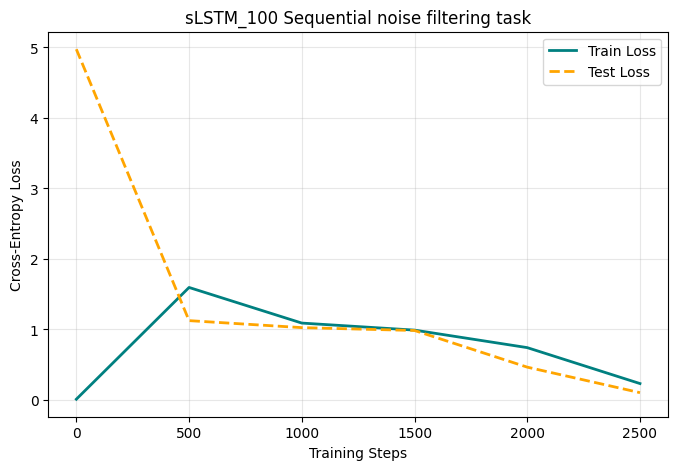

STEP: 2500 | TRAIN LOSS: 0.2322 | TEST LOSS: 0.1029


  0%|          | 0/10 [00:00<?, ?it/s]

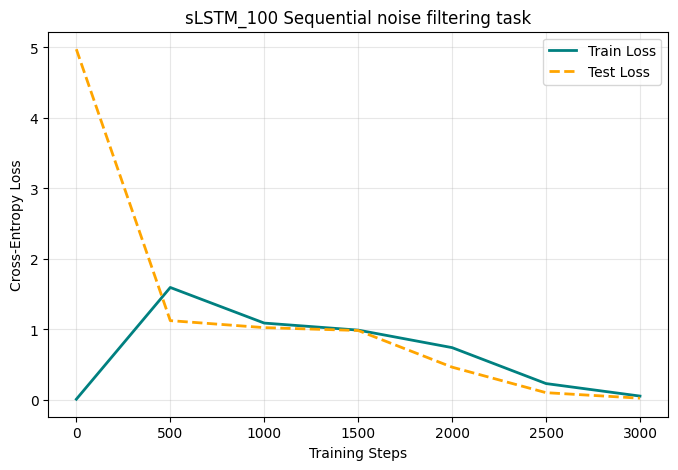

STEP: 3000 | TRAIN LOSS: 0.0545 | TEST LOSS: 0.0248


  0%|          | 0/10 [00:00<?, ?it/s]

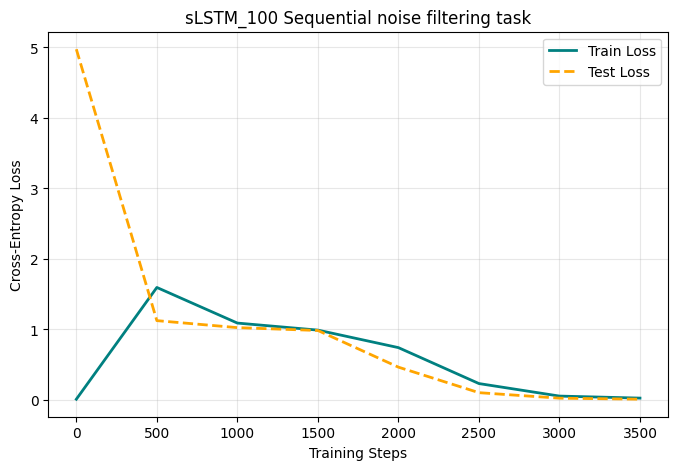

STEP: 3500 | TRAIN LOSS: 0.0259 | TEST LOSS: 0.0103


  0%|          | 0/10 [00:00<?, ?it/s]

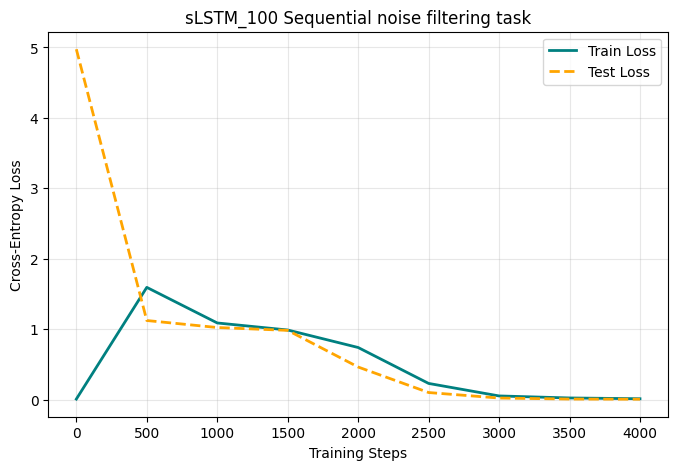

STEP: 4000 | TRAIN LOSS: 0.0149 | TEST LOSS: 0.0080


  0%|          | 0/10 [00:00<?, ?it/s]

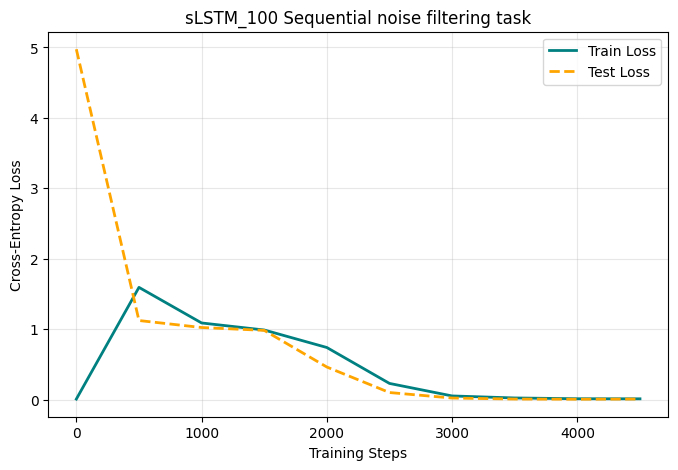

STEP: 4500 | TRAIN LOSS: 0.0139 | TEST LOSS: 0.0103


  0%|          | 0/10 [00:00<?, ?it/s]

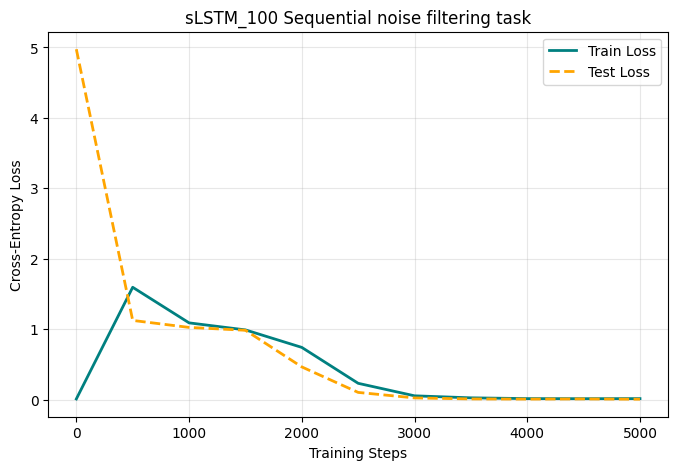

STEP: 5000 | TRAIN LOSS: 0.0150 | TEST LOSS: 0.0062


  0%|          | 0/10 [00:00<?, ?it/s]

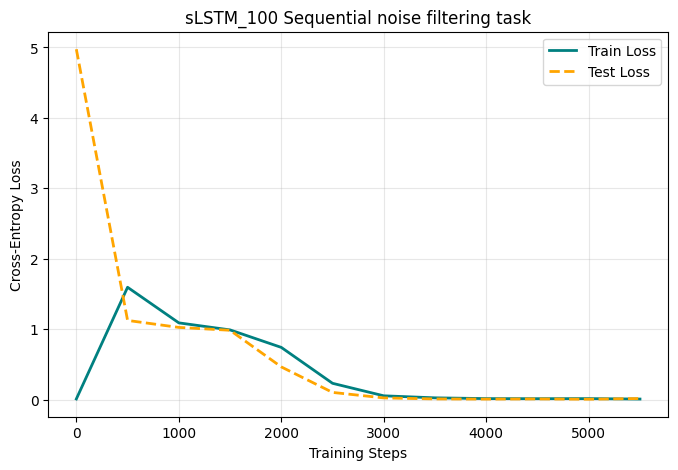

STEP: 5500 | TRAIN LOSS: 0.0086 | TEST LOSS: 0.0161


  0%|          | 0/10 [00:00<?, ?it/s]

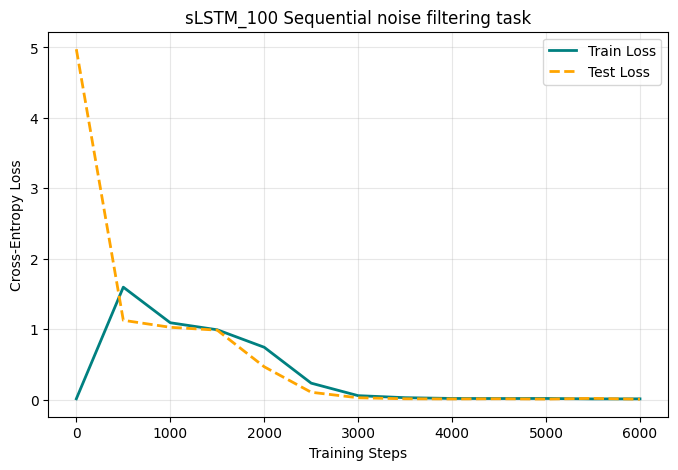

STEP: 6000 | TRAIN LOSS: 0.0094 | TEST LOSS: 0.0040


  0%|          | 0/10 [00:00<?, ?it/s]

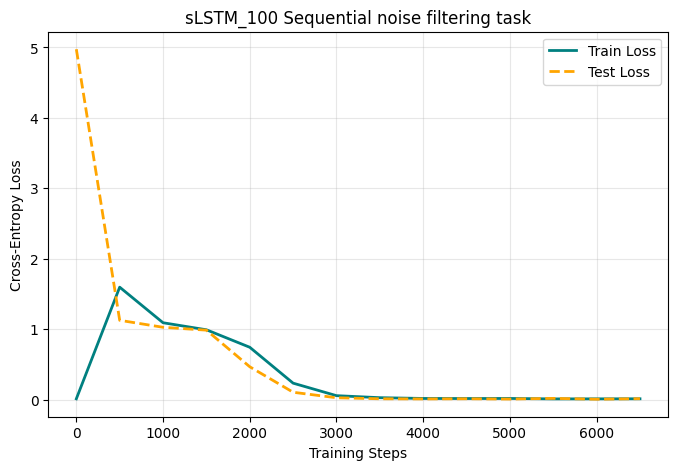

STEP: 6500 | TRAIN LOSS: 0.0102 | TEST LOSS: 0.0115


  0%|          | 0/10 [00:00<?, ?it/s]

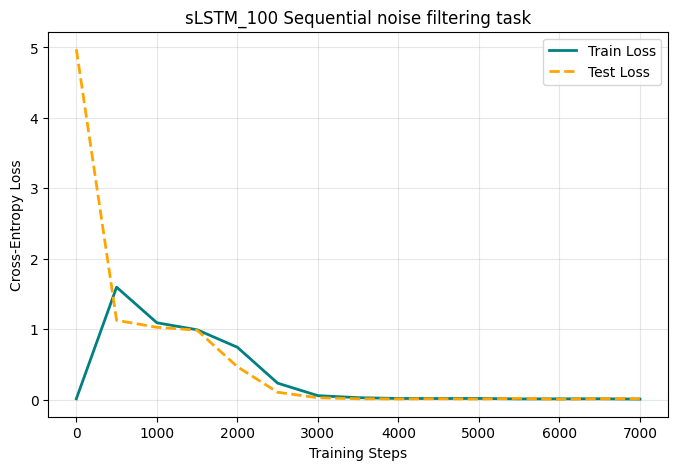

STEP: 7000 | TRAIN LOSS: 0.0060 | TEST LOSS: 0.0102


In [5]:
run_training_ex2(sLSTM_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_sLSTM, 
                 test_break=500, 
                 model_name="sLSTM_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

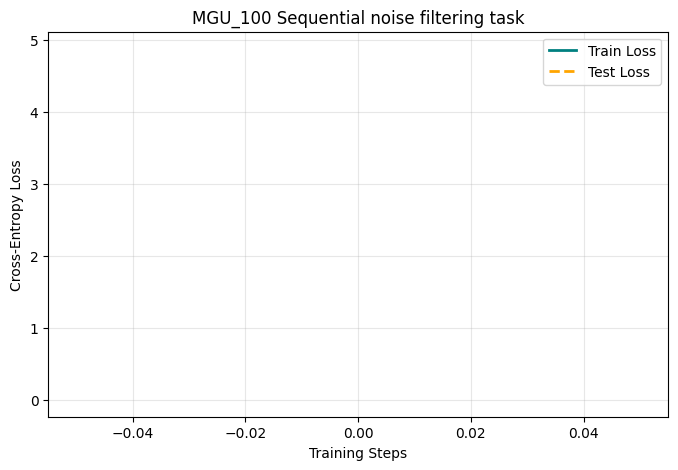

STEP: 0 | TRAIN LOSS: 0.0099 | TEST LOSS: 4.8735


  0%|          | 0/10 [00:00<?, ?it/s]

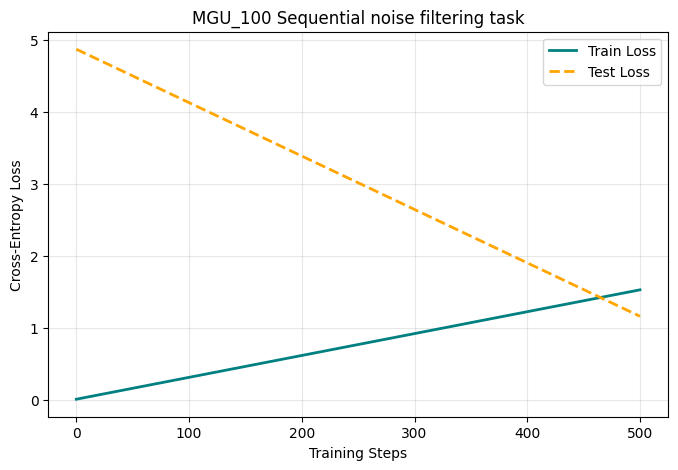

STEP: 500 | TRAIN LOSS: 1.5300 | TEST LOSS: 1.1625


  0%|          | 0/10 [00:00<?, ?it/s]

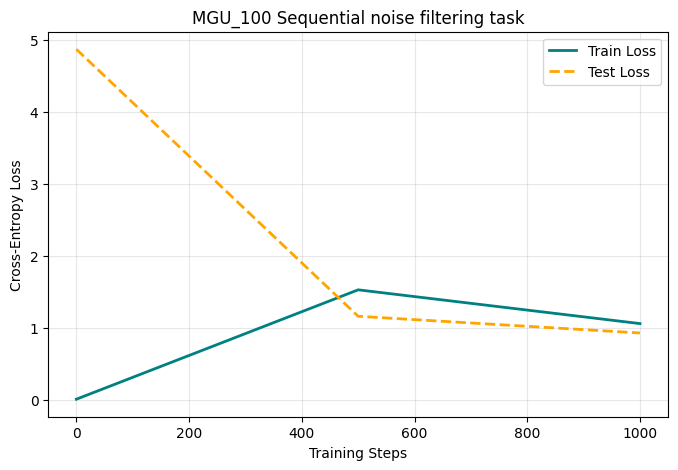

STEP: 1000 | TRAIN LOSS: 1.0610 | TEST LOSS: 0.9304


  0%|          | 0/10 [00:00<?, ?it/s]

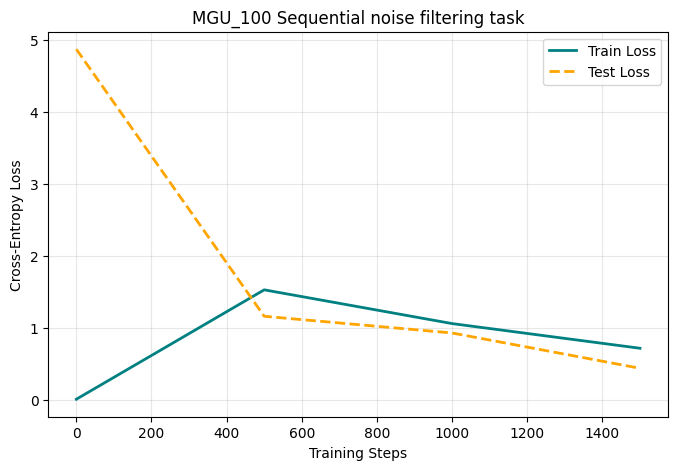

STEP: 1500 | TRAIN LOSS: 0.7181 | TEST LOSS: 0.4398


  0%|          | 0/10 [00:00<?, ?it/s]

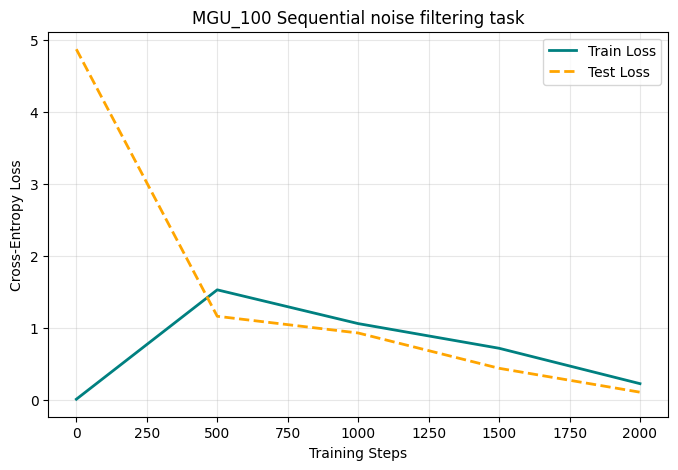

STEP: 2000 | TRAIN LOSS: 0.2262 | TEST LOSS: 0.1075


  0%|          | 0/10 [00:00<?, ?it/s]

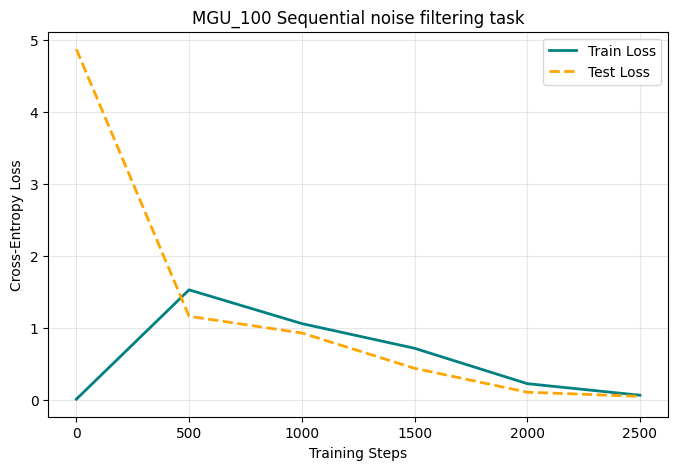

STEP: 2500 | TRAIN LOSS: 0.0653 | TEST LOSS: 0.0497


  0%|          | 0/10 [00:00<?, ?it/s]

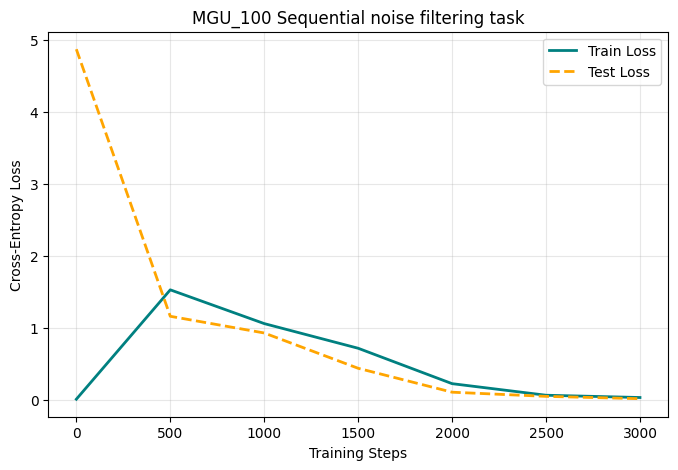

STEP: 3000 | TRAIN LOSS: 0.0337 | TEST LOSS: 0.0173


  0%|          | 0/10 [00:00<?, ?it/s]

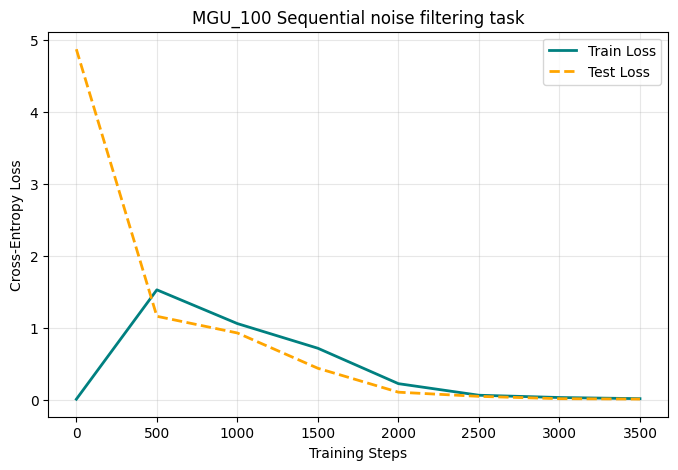

STEP: 3500 | TRAIN LOSS: 0.0177 | TEST LOSS: 0.0119


  0%|          | 0/10 [00:00<?, ?it/s]

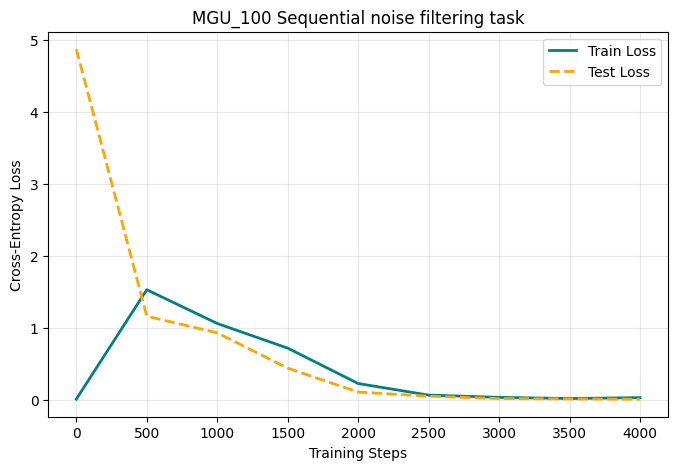

STEP: 4000 | TRAIN LOSS: 0.0300 | TEST LOSS: 0.0079


  0%|          | 0/10 [00:00<?, ?it/s]

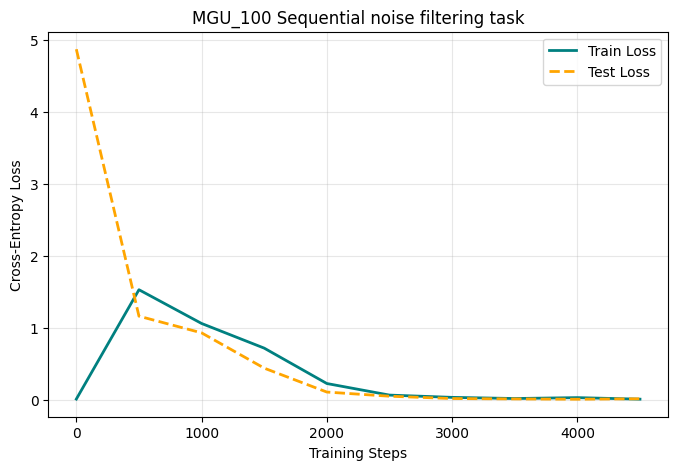

STEP: 4500 | TRAIN LOSS: 0.0086 | TEST LOSS: 0.0140


  0%|          | 0/10 [00:00<?, ?it/s]

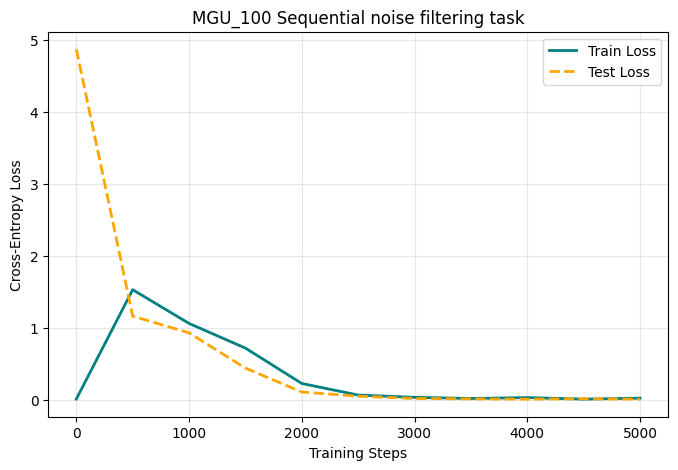

STEP: 5000 | TRAIN LOSS: 0.0225 | TEST LOSS: 0.0075


  0%|          | 0/10 [00:00<?, ?it/s]

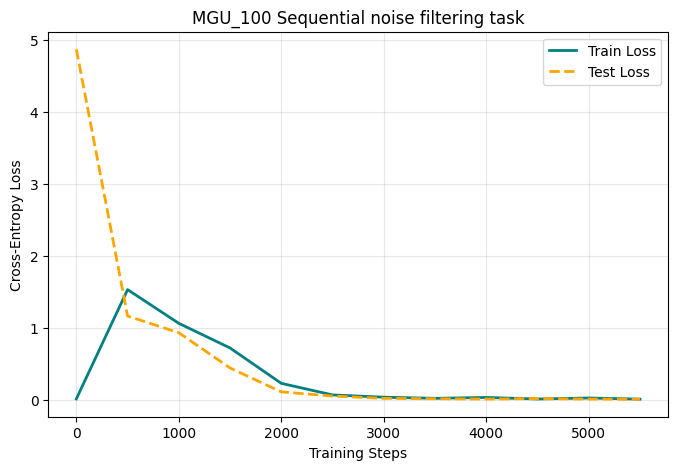

STEP: 5500 | TRAIN LOSS: 0.0064 | TEST LOSS: 0.0054


  0%|          | 0/10 [00:00<?, ?it/s]

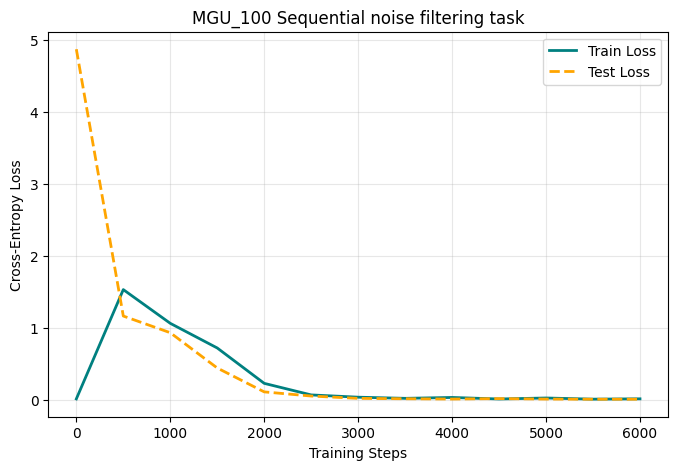

STEP: 6000 | TRAIN LOSS: 0.0111 | TEST LOSS: 0.0056


  0%|          | 0/10 [00:00<?, ?it/s]

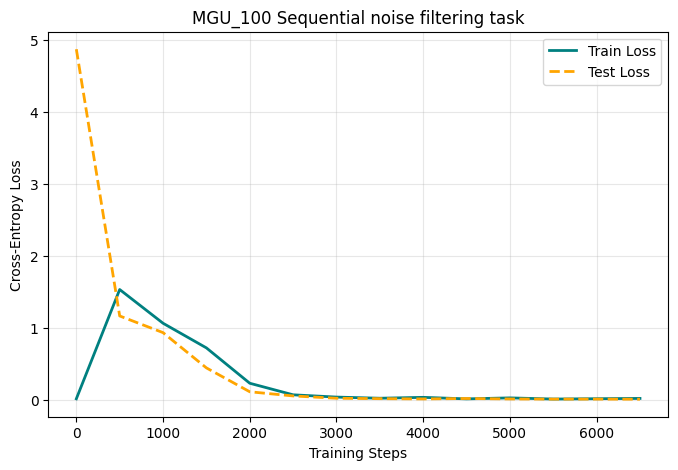

STEP: 6500 | TRAIN LOSS: 0.0150 | TEST LOSS: 0.0039


  0%|          | 0/10 [00:00<?, ?it/s]

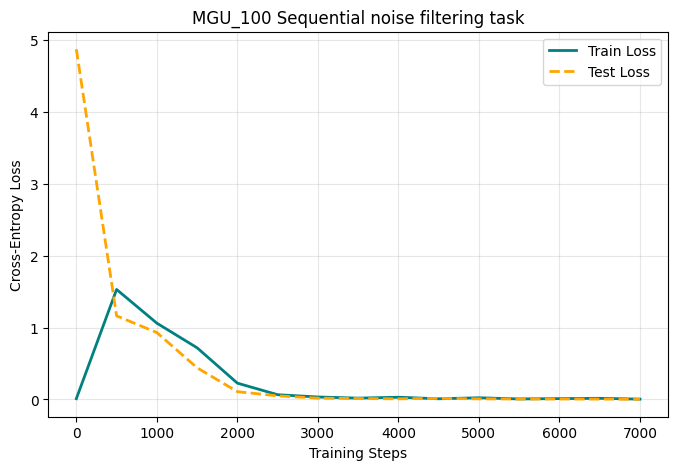

STEP: 7000 | TRAIN LOSS: 0.0038 | TEST LOSS: 0.0024


In [7]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(MGU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_MGU, 
                 test_break=500, 
                 model_name="MGU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

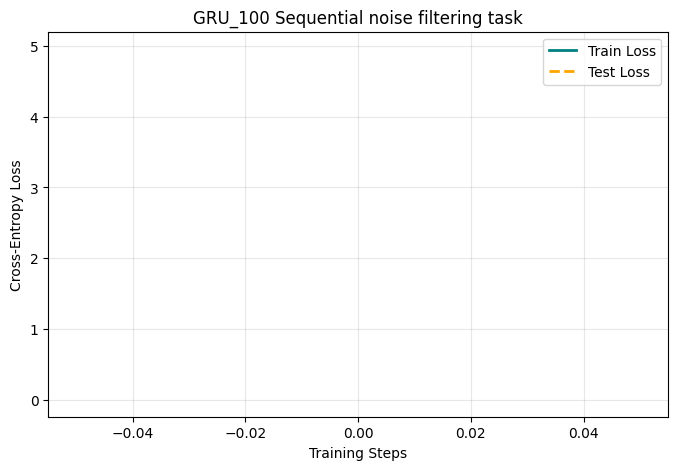

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9527


  0%|          | 0/10 [00:00<?, ?it/s]

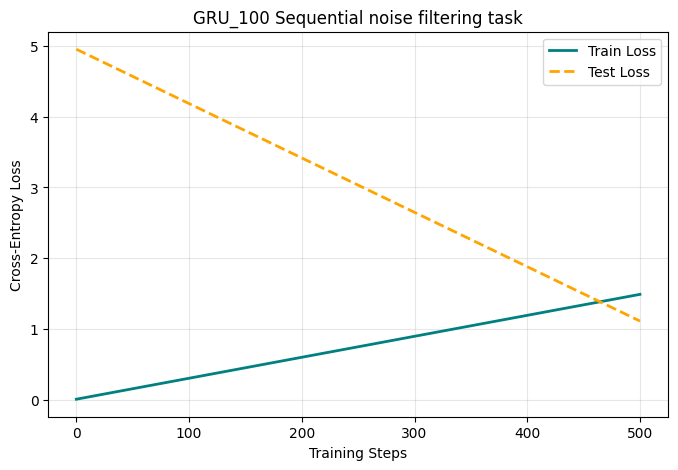

STEP: 500 | TRAIN LOSS: 1.4909 | TEST LOSS: 1.1136


  0%|          | 0/10 [00:00<?, ?it/s]

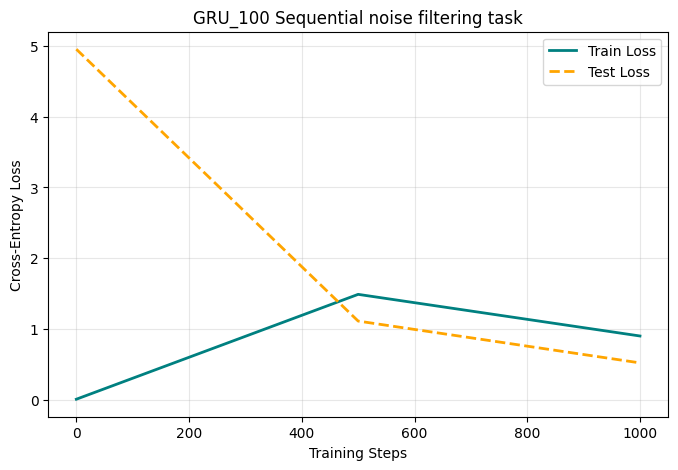

STEP: 1000 | TRAIN LOSS: 0.9028 | TEST LOSS: 0.5231


  0%|          | 0/10 [00:00<?, ?it/s]

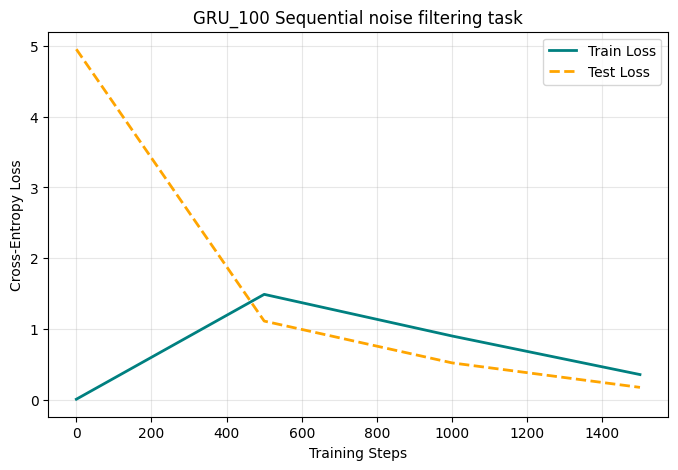

STEP: 1500 | TRAIN LOSS: 0.3583 | TEST LOSS: 0.1771


  0%|          | 0/10 [00:00<?, ?it/s]

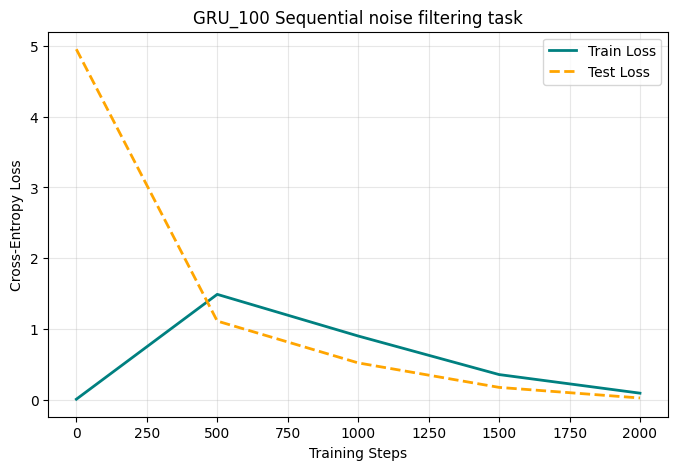

STEP: 2000 | TRAIN LOSS: 0.0954 | TEST LOSS: 0.0273


  0%|          | 0/10 [00:00<?, ?it/s]

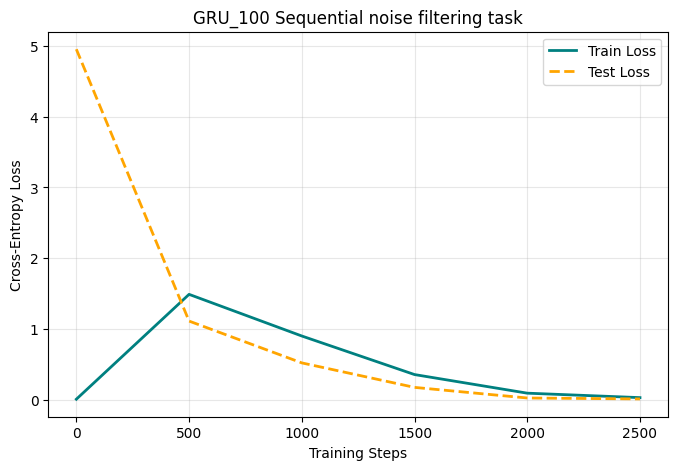

STEP: 2500 | TRAIN LOSS: 0.0325 | TEST LOSS: 0.0140


  0%|          | 0/10 [00:00<?, ?it/s]

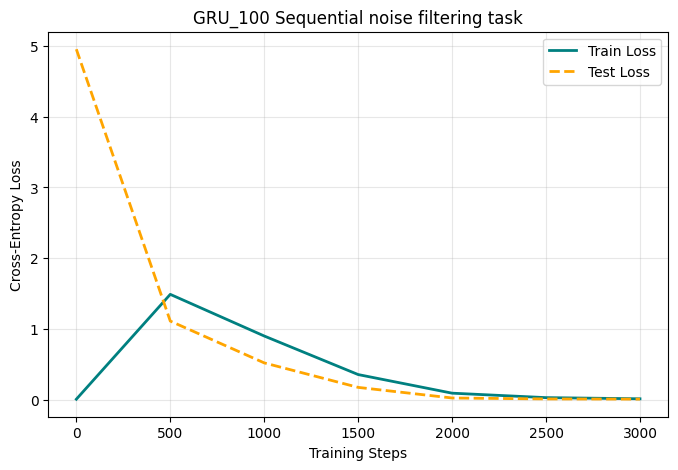

STEP: 3000 | TRAIN LOSS: 0.0161 | TEST LOSS: 0.0114


  0%|          | 0/10 [00:00<?, ?it/s]

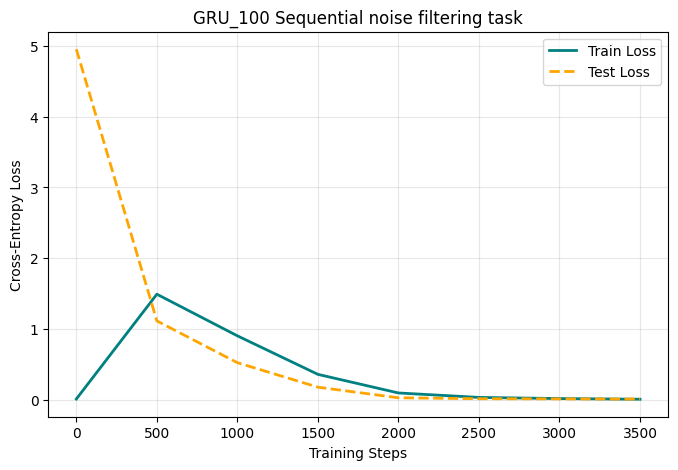

STEP: 3500 | TRAIN LOSS: 0.0070 | TEST LOSS: 0.0089


  0%|          | 0/10 [00:00<?, ?it/s]

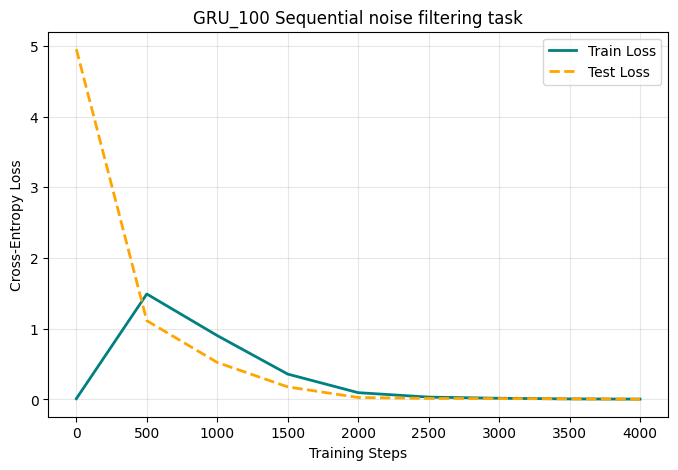

STEP: 4000 | TRAIN LOSS: 0.0043 | TEST LOSS: 0.0026


  0%|          | 0/10 [00:00<?, ?it/s]

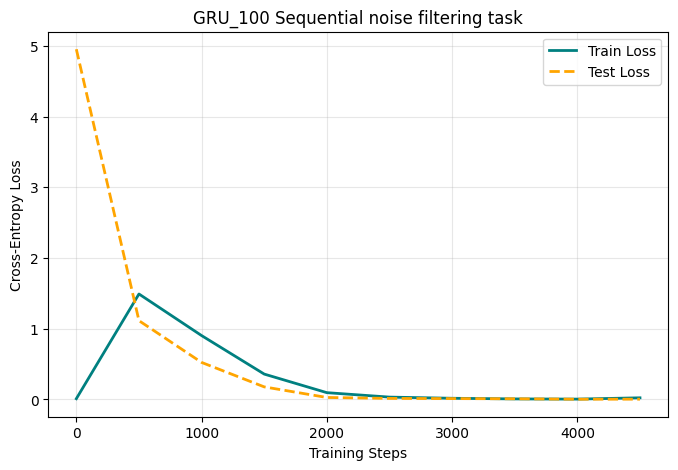

STEP: 4500 | TRAIN LOSS: 0.0225 | TEST LOSS: 0.0033


  0%|          | 0/10 [00:00<?, ?it/s]

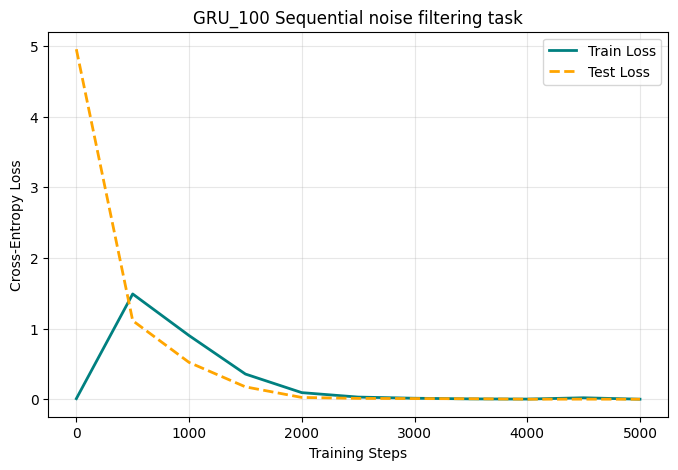

STEP: 5000 | TRAIN LOSS: 0.0026 | TEST LOSS: 0.0022


  0%|          | 0/10 [00:00<?, ?it/s]

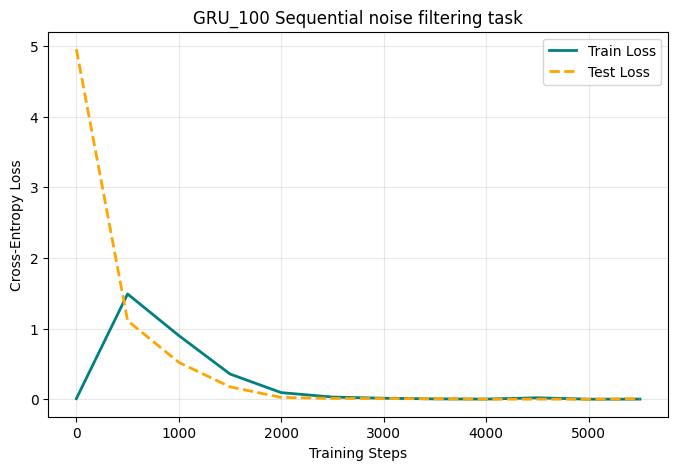

STEP: 5500 | TRAIN LOSS: 0.0038 | TEST LOSS: 0.0090


  0%|          | 0/10 [00:00<?, ?it/s]

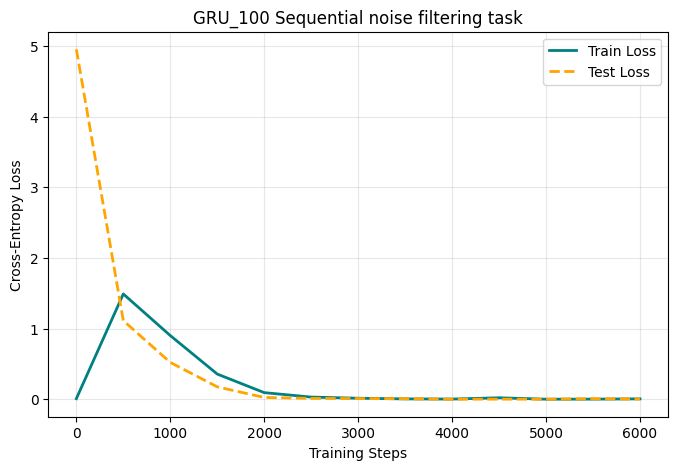

STEP: 6000 | TRAIN LOSS: 0.0073 | TEST LOSS: 0.0046


  0%|          | 0/10 [00:00<?, ?it/s]

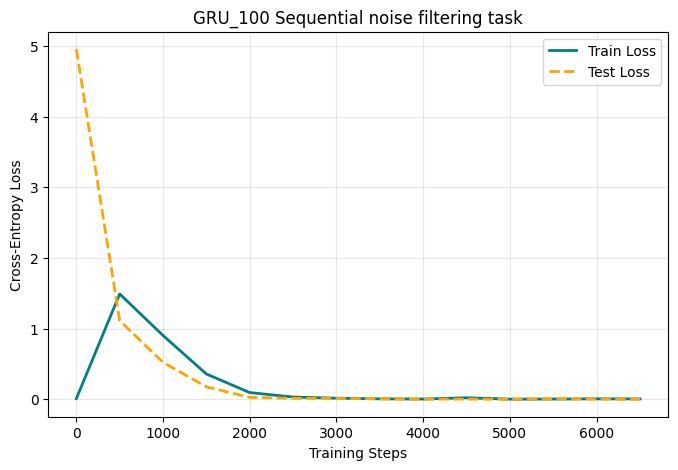

STEP: 6500 | TRAIN LOSS: 0.0058 | TEST LOSS: 0.0016


  0%|          | 0/10 [00:00<?, ?it/s]

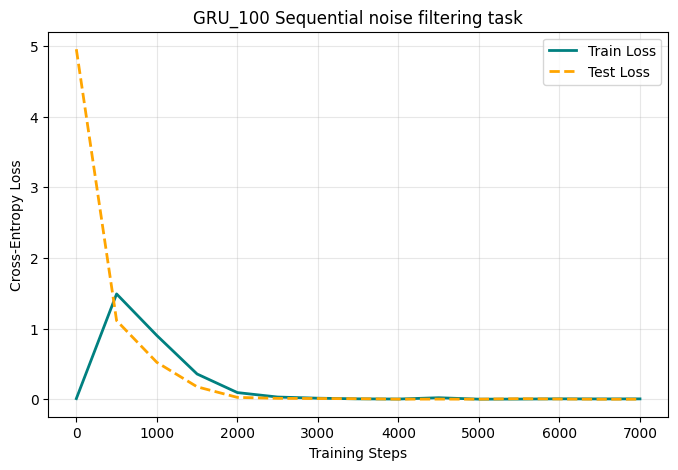

STEP: 7000 | TRAIN LOSS: 0.0066 | TEST LOSS: 0.0021


In [8]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(GRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_GRU, 
                 test_break=500, 
                 model_name="GRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

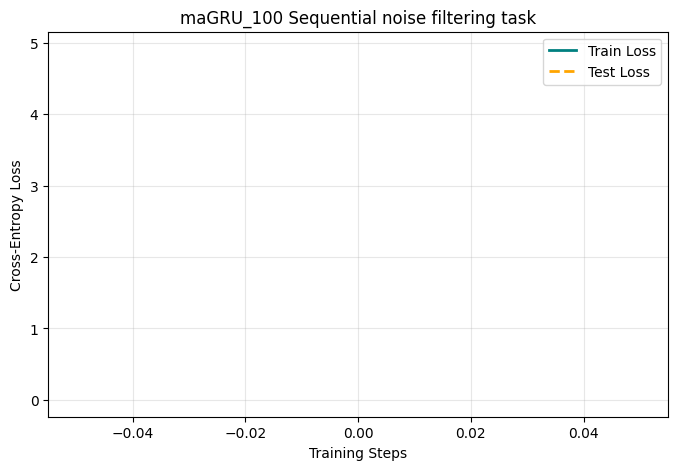

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9074


  0%|          | 0/10 [00:00<?, ?it/s]

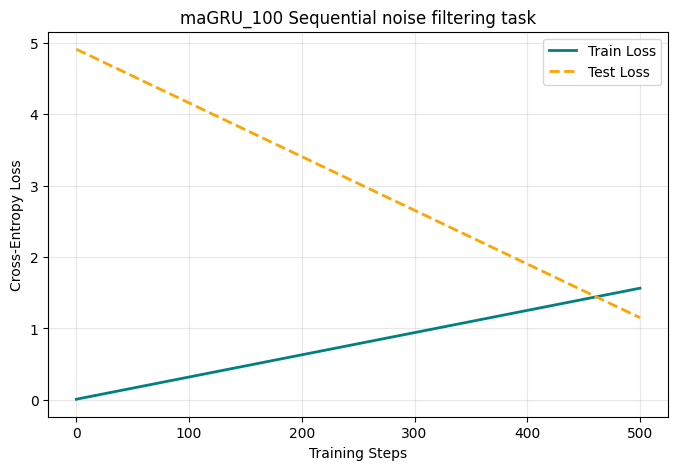

STEP: 500 | TRAIN LOSS: 1.5635 | TEST LOSS: 1.1511


  0%|          | 0/10 [00:00<?, ?it/s]

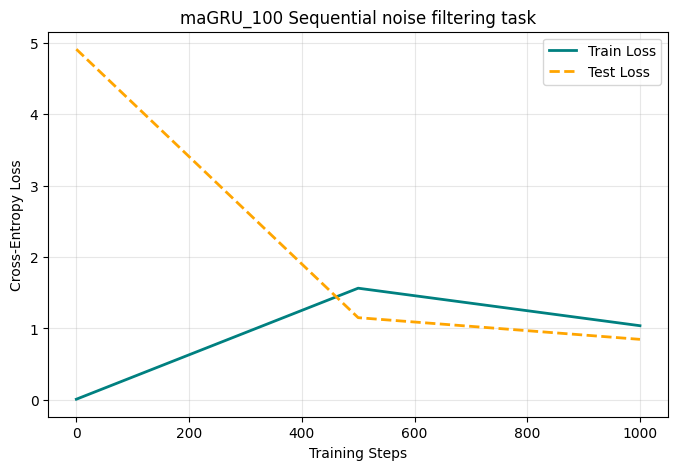

STEP: 1000 | TRAIN LOSS: 1.0386 | TEST LOSS: 0.8477


  0%|          | 0/10 [00:00<?, ?it/s]

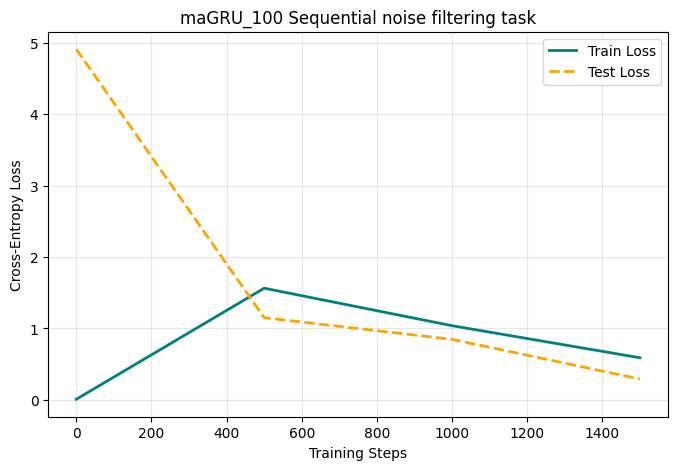

STEP: 1500 | TRAIN LOSS: 0.5900 | TEST LOSS: 0.2922


  0%|          | 0/10 [00:00<?, ?it/s]

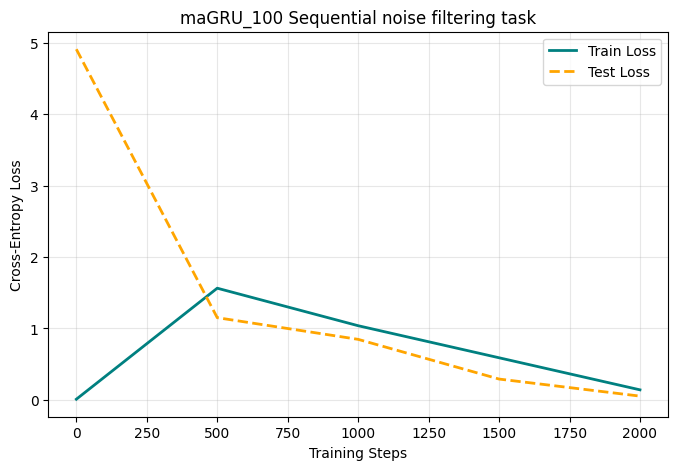

STEP: 2000 | TRAIN LOSS: 0.1413 | TEST LOSS: 0.0534


  0%|          | 0/10 [00:00<?, ?it/s]

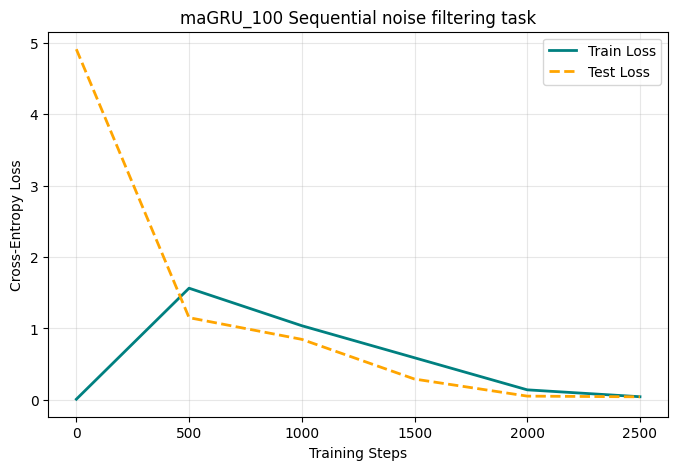

STEP: 2500 | TRAIN LOSS: 0.0449 | TEST LOSS: 0.0434


  0%|          | 0/10 [00:00<?, ?it/s]

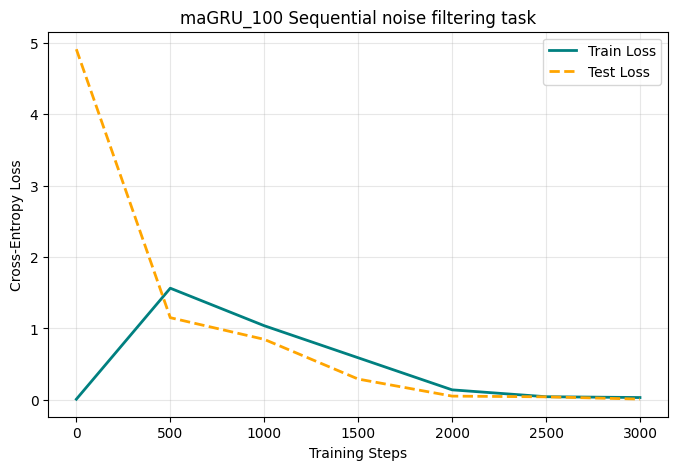

STEP: 3000 | TRAIN LOSS: 0.0336 | TEST LOSS: 0.0119


  0%|          | 0/10 [00:00<?, ?it/s]

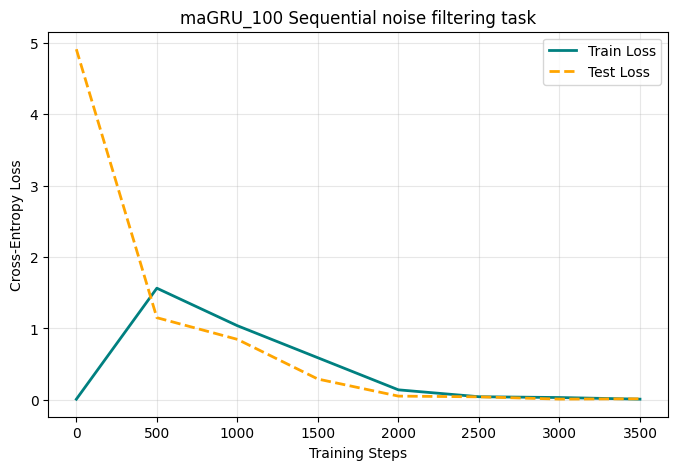

STEP: 3500 | TRAIN LOSS: 0.0108 | TEST LOSS: 0.0158


  0%|          | 0/10 [00:00<?, ?it/s]

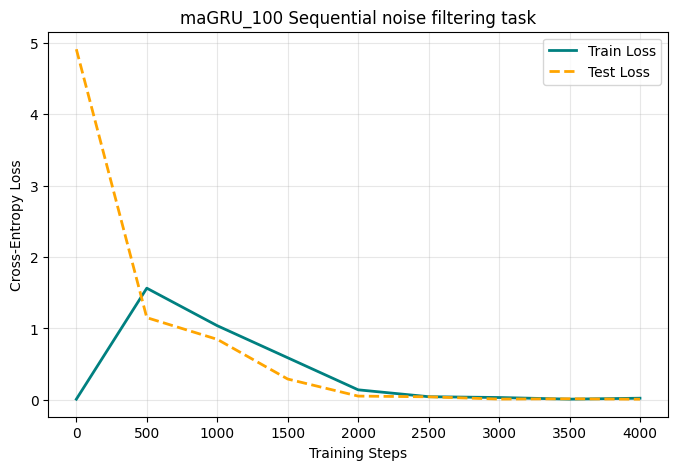

STEP: 4000 | TRAIN LOSS: 0.0238 | TEST LOSS: 0.0097


  0%|          | 0/10 [00:00<?, ?it/s]

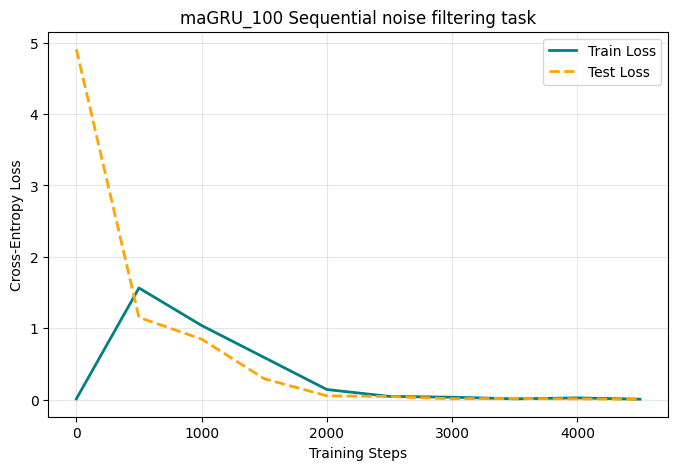

STEP: 4500 | TRAIN LOSS: 0.0062 | TEST LOSS: 0.0055


  0%|          | 0/10 [00:00<?, ?it/s]

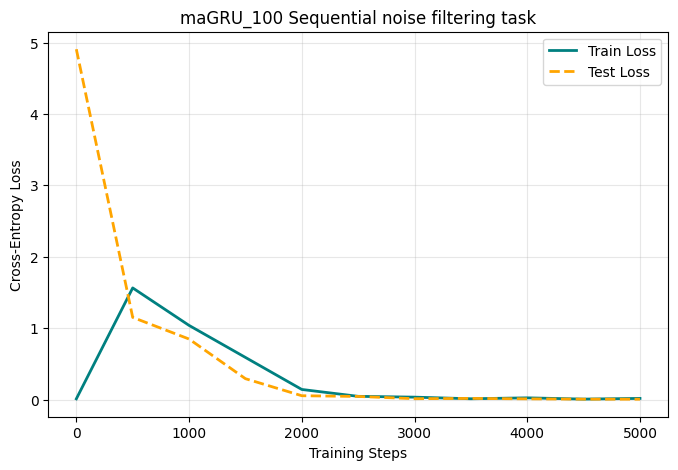

STEP: 5000 | TRAIN LOSS: 0.0159 | TEST LOSS: 0.0045


  0%|          | 0/10 [00:00<?, ?it/s]

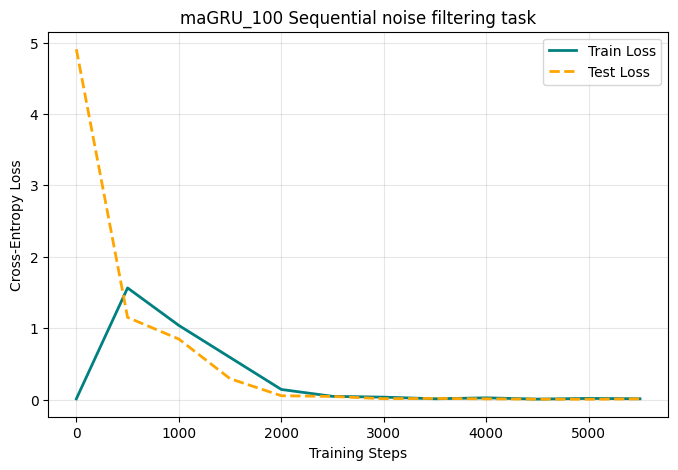

STEP: 5500 | TRAIN LOSS: 0.0109 | TEST LOSS: 0.0093


  0%|          | 0/10 [00:00<?, ?it/s]

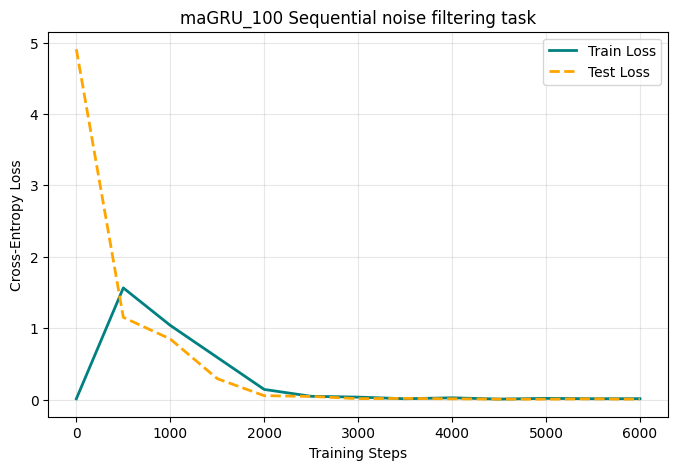

STEP: 6000 | TRAIN LOSS: 0.0117 | TEST LOSS: 0.0041


  0%|          | 0/10 [00:00<?, ?it/s]

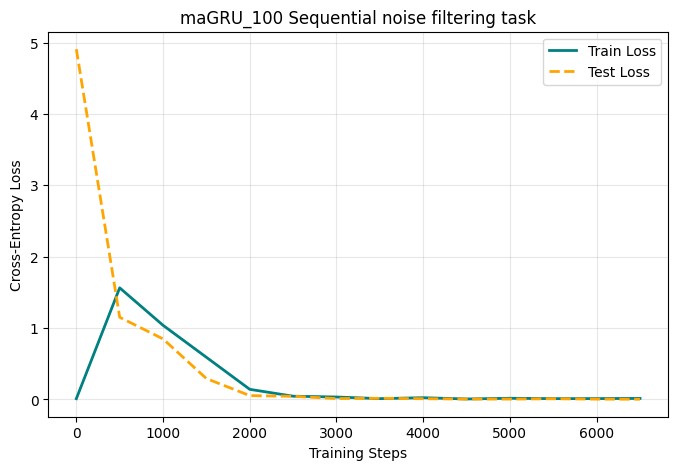

STEP: 6500 | TRAIN LOSS: 0.0140 | TEST LOSS: 0.0027


  0%|          | 0/10 [00:00<?, ?it/s]

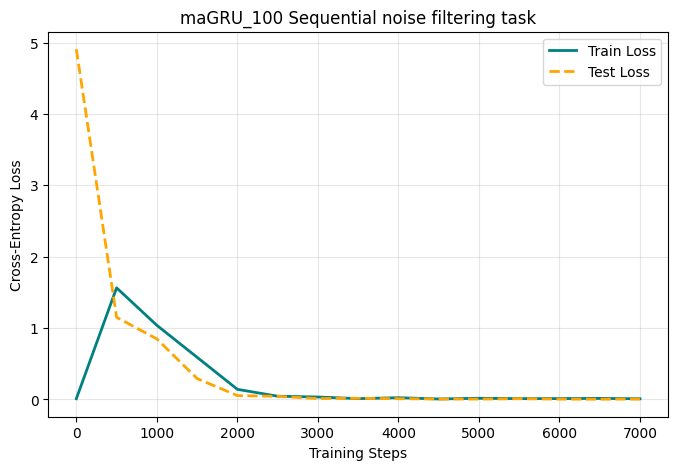

STEP: 7000 | TRAIN LOSS: 0.0094 | TEST LOSS: 0.0051


In [9]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(maGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_maGRU, 
                 test_break=500, 
                 model_name="maGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

  0%|          | 0/7001 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

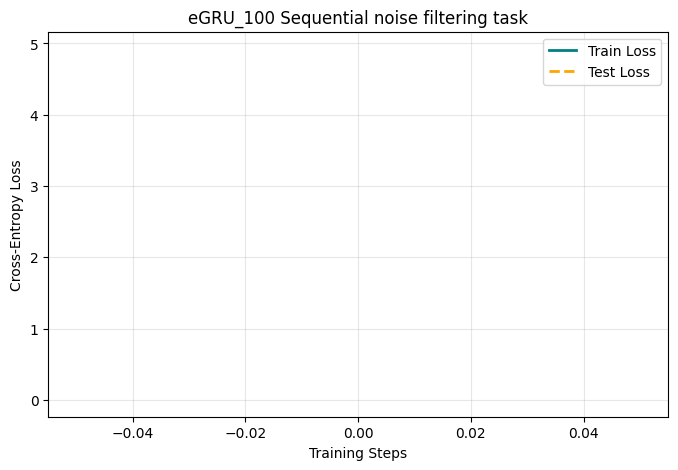

STEP: 0 | TRAIN LOSS: 0.0100 | TEST LOSS: 4.9190


  0%|          | 0/10 [00:00<?, ?it/s]

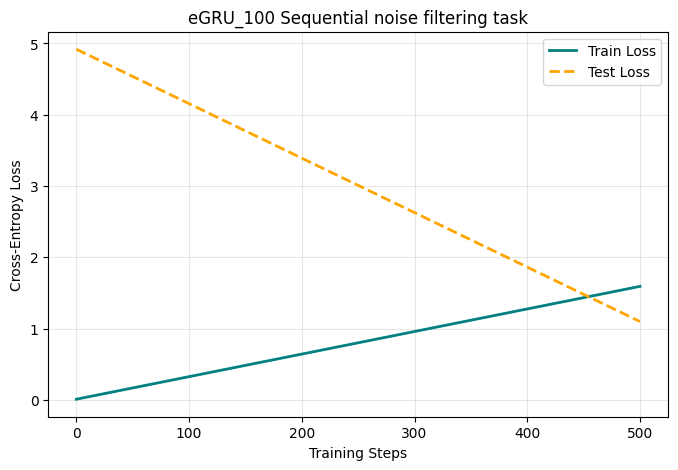

STEP: 500 | TRAIN LOSS: 1.5928 | TEST LOSS: 1.0994


  0%|          | 0/10 [00:00<?, ?it/s]

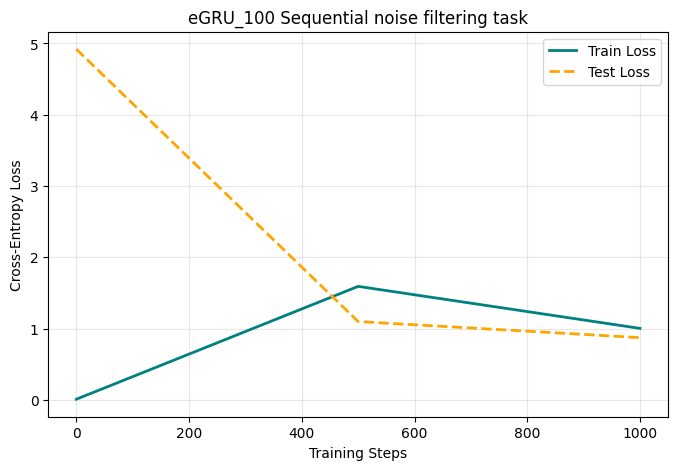

STEP: 1000 | TRAIN LOSS: 1.0036 | TEST LOSS: 0.8738


  0%|          | 0/10 [00:00<?, ?it/s]

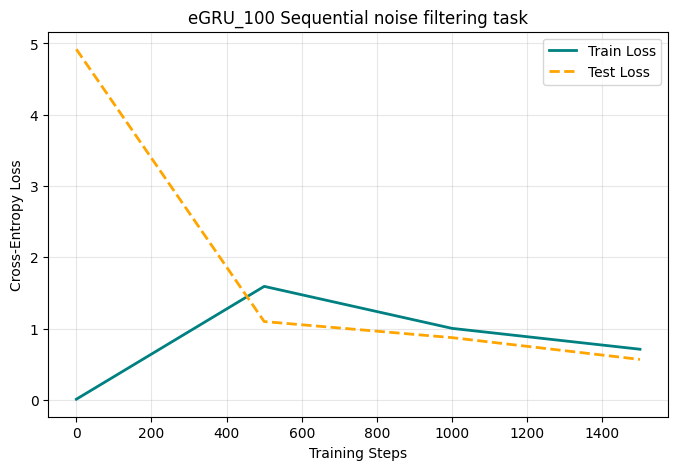

STEP: 1500 | TRAIN LOSS: 0.7110 | TEST LOSS: 0.5681


  0%|          | 0/10 [00:00<?, ?it/s]

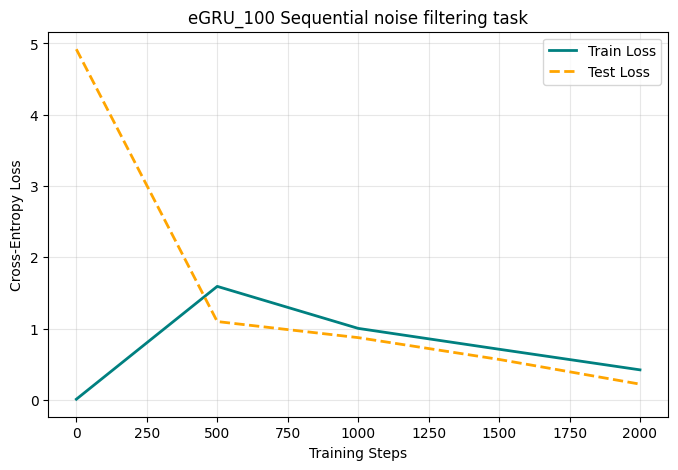

STEP: 2000 | TRAIN LOSS: 0.4219 | TEST LOSS: 0.2215


  0%|          | 0/10 [00:00<?, ?it/s]

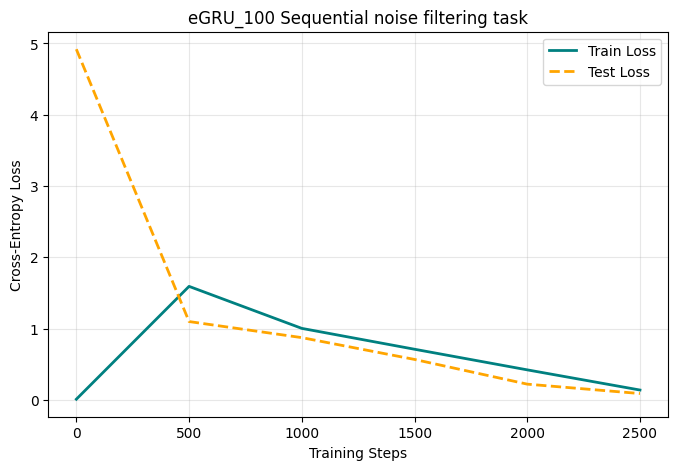

STEP: 2500 | TRAIN LOSS: 0.1388 | TEST LOSS: 0.0896


  0%|          | 0/10 [00:00<?, ?it/s]

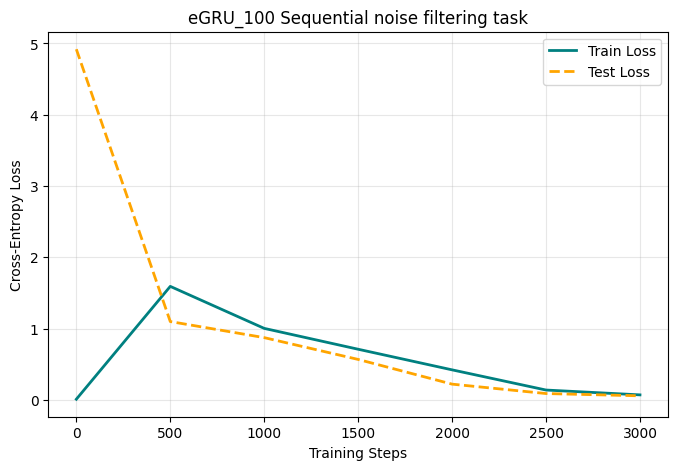

STEP: 3000 | TRAIN LOSS: 0.0710 | TEST LOSS: 0.0578


  0%|          | 0/10 [00:00<?, ?it/s]

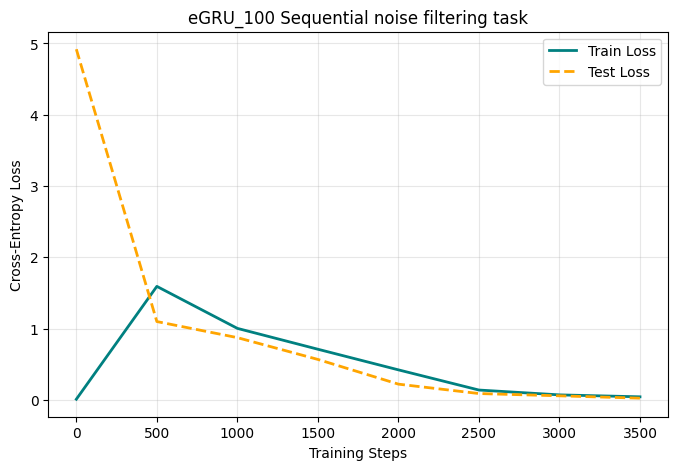

STEP: 3500 | TRAIN LOSS: 0.0437 | TEST LOSS: 0.0247


  0%|          | 0/10 [00:00<?, ?it/s]

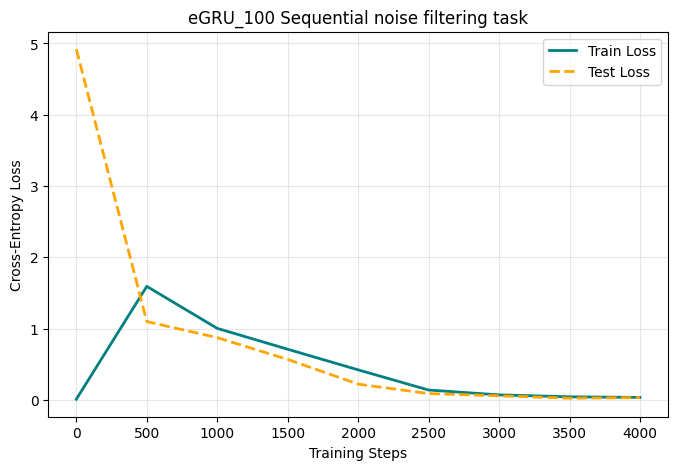

STEP: 4000 | TRAIN LOSS: 0.0352 | TEST LOSS: 0.0332


  0%|          | 0/10 [00:00<?, ?it/s]

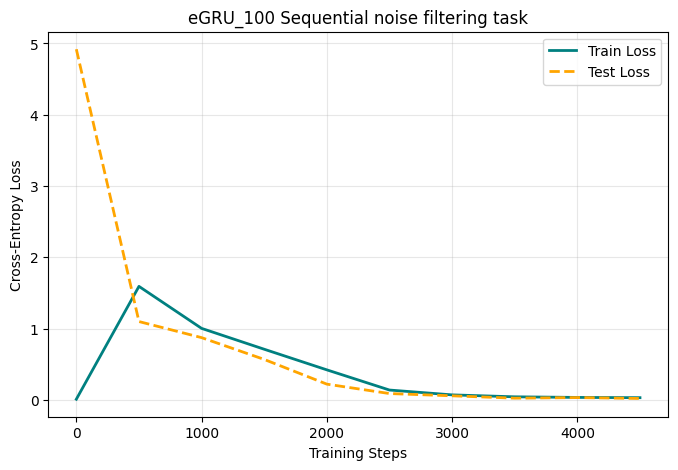

STEP: 4500 | TRAIN LOSS: 0.0317 | TEST LOSS: 0.0205


  0%|          | 0/10 [00:00<?, ?it/s]

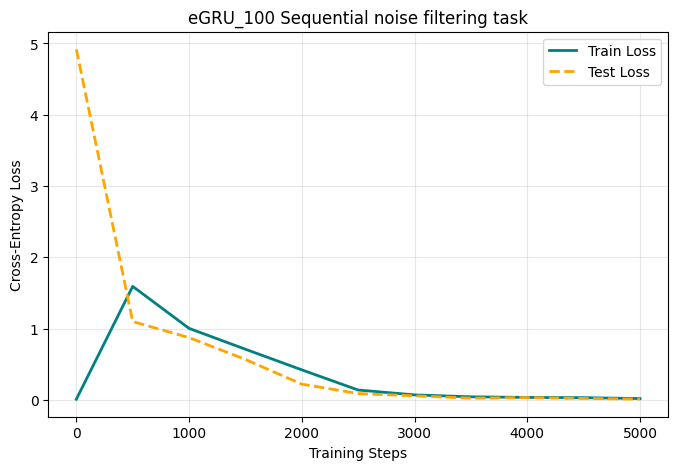

STEP: 5000 | TRAIN LOSS: 0.0190 | TEST LOSS: 0.0112


  0%|          | 0/10 [00:00<?, ?it/s]

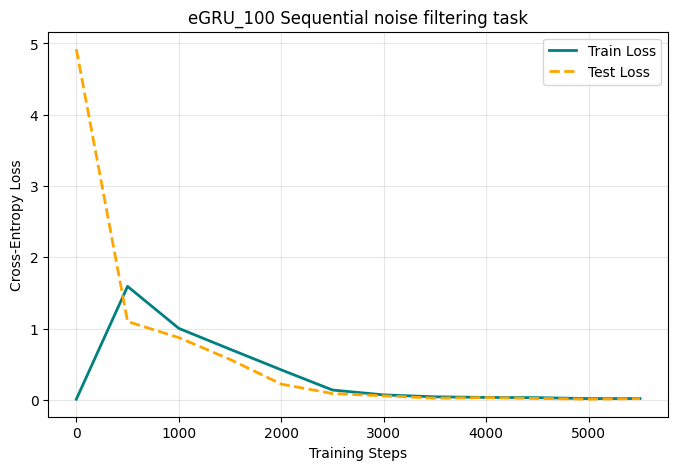

STEP: 5500 | TRAIN LOSS: 0.0198 | TEST LOSS: 0.0176


  0%|          | 0/10 [00:00<?, ?it/s]

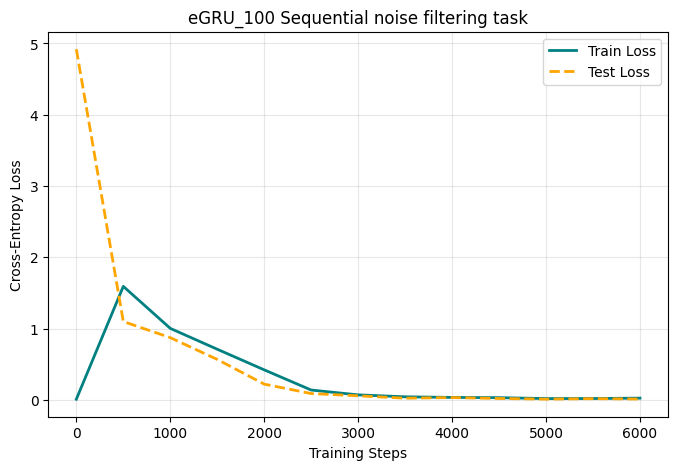

STEP: 6000 | TRAIN LOSS: 0.0252 | TEST LOSS: 0.0124


  0%|          | 0/10 [00:00<?, ?it/s]

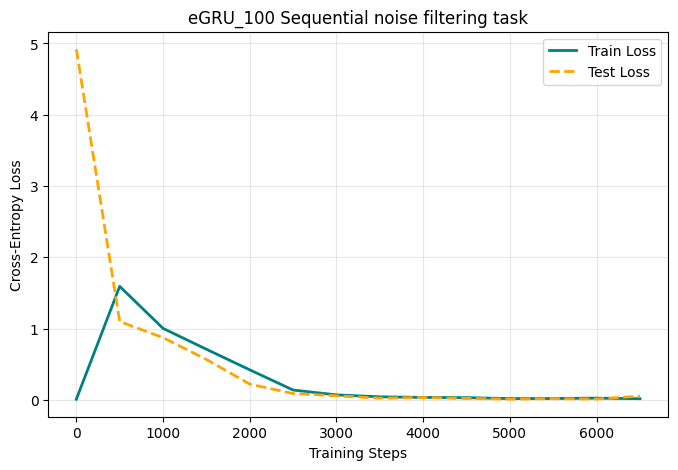

STEP: 6500 | TRAIN LOSS: 0.0170 | TEST LOSS: 0.0539


  0%|          | 0/10 [00:00<?, ?it/s]

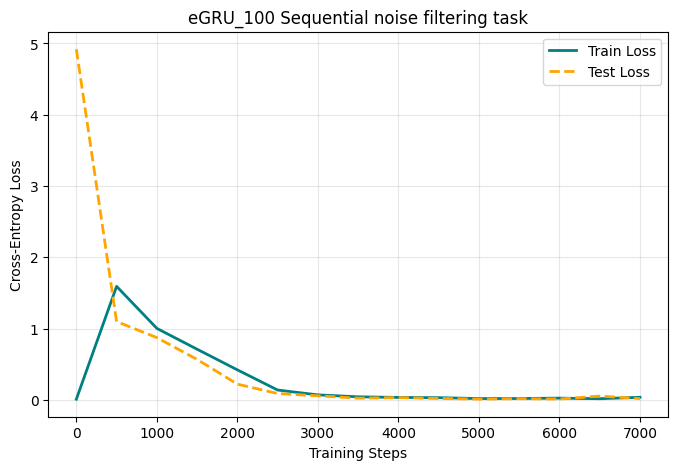

STEP: 7000 | TRAIN LOSS: 0.0371 | TEST LOSS: 0.0191


In [10]:
steps_history = []
train_history = []
test_history = []

run_training_ex2(eGRU_model, 
                 batch_size, 
                 total_batches, 
                 test_batches, 
                 copy_size, 
                 buffer_size, 
                 opt_eGRU, 
                 test_break=500, 
                 model_name="eGRU_100",
                 steps_history=steps_history,
                 train_history=train_history,
                 test_history=test_history,
                 vocab=vocab)

## Testing the models!

In [11]:
def load_model(filename, device, model, optimizer):
    checkpoint = torch.load(filename, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
    start_epoch = checkpoint["epoch_saved"] + 1
    return start_epoch

In [ ]:
hid=256
emb=len(vocab)
lr=1e-3
batch_size=32
test_batches=100

steps_history = []
train_history = []
test_history = []

load_model("./models/ex2/sLSTM_100_ex2_epoch_7000.pt", "cuda", sLSTM_model, opt_sLSTM)
load_model("./models/ex2/MGU_100_ex2_epoch_7000.pt", "cuda", MGU_model, opt_MGU)
load_model("./models/ex2/maGRU_100_ex2_epoch_7000.pt", "cuda", maGRU_model, opt_maGRU)
load_model("./models/ex2/GRU_100_ex2_epoch_7000.pt", "cuda", GRU_model, opt_GRU)
load_model("./models/ex2/eGRU_100_ex2_epoch_7000.pt", "cuda", eGRU_model, opt_eGRU)

In [ ]:
ex1_cgru_50 =     evaluate_ex2(GRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_100 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_250 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_500 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_750 =   evaluate_ex2(GRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_cgru_1000 = evaluate_ex2(GRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("GRU sequential noise filtering at buffer_size=50: ", ex1_cgru_50)
print("GRU sequential noise filtering at buffer_size=100: ", ex1_cgru_100)
print("GRU sequential noise filtering at buffer_size=250: ", ex1_cgru_250)
print("GRU sequential noise filtering at buffer_size=500: ", ex1_cgru_500)
print("GRU sequential noise filtering at buffer_size=750: ", ex1_cgru_750)
print("GRU sequential noise filtering at buffer_size=1000: ", ex1_cgru_1000)

In [ ]:
ex1_mgu_50 =     evaluate_ex2(MGU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_100 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_250 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_500 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_750 =   evaluate_ex2(MGU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_mgu_1000 = evaluate_ex2(MGU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("MGU sequential noise filtering at buffer_size=50: ",   ex1_mgu_50)
print("MGU sequential noise filtering at buffer_size=100: ",  ex1_mgu_100)
print("MGU sequential noise filtering at buffer_size=250: ",  ex1_mgu_250)
print("MGU sequential noise filtering at buffer_size=500: ",  ex1_mgu_500)
print("MGU sequential noise filtering at buffer_size=750: ",  ex1_mgu_750)
print("MGU sequential noise filtering at buffer_size=1000: ", ex1_mgu_1000)

In [6]:
ex1_slstm_50 =     evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_100 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_250 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_500 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_750 =   evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_slstm_1000 = evaluate_ex2(sLSTM_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("sLSTM sequential noise filtering difference at buffer_size=50: ",   ex1_slstm_50)
print("sLSTM sequential noise filtering difference at buffer_size=100: ",  ex1_slstm_100)
print("sLSTM sequential noise filtering difference at buffer_size=250: ",  ex1_slstm_250)
print("sLSTM sequential noise filtering difference at buffer_size=500: ",  ex1_slstm_500)
print("sLSTM sequential noise filtering difference at buffer_size=750: ",  ex1_slstm_750)
print("sLSTM sequential noise filtering difference at buffer_size=1000: ", ex1_slstm_1000)

Testing model at  50  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/11 [00:00<?, ?it/s]

sLSTM sequential noise filtering difference at buffer_size=50:  0.00227272732775997
sLSTM sequential noise filtering difference at buffer_size=100:  0.001988636393269355
sLSTM sequential noise filtering difference at buffer_size=250:  0.019318182148378004
sLSTM sequential noise filtering difference at buffer_size=500:  0.08863636512647975
sLSTM sequential noise filtering difference at buffer_size=750:  0.15028409524397415
sLSTM sequential noise filtering difference at buffer_size=1000:  0.21988636661659589


In [ ]:
ex1_magru_50 =     evaluate_ex2(maGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_100 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_250 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_500 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_750 =   evaluate_ex2(maGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_magru_1000 = evaluate_ex2(maGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("maGRU sequential noise filtering difference at buffer_size=50: ",   ex1_magru_50)
print("maGRU sequential noise filtering difference at buffer_size=100: ",  ex1_magru_100)
print("maGRU sequential noise filtering difference at buffer_size=250: ",  ex1_magru_250)
print("maGRU sequential noise filtering difference at buffer_size=500: ",  ex1_magru_500)
print("maGRU sequential noise filtering difference at buffer_size=750: ",  ex1_magru_750)
print("maGRU sequential noise filtering difference at buffer_size=1000: ", ex1_magru_1000)

In [ ]:
ex1_eGRU_50 =     evaluate_ex2(eGRU_model, copy_size=10, buffer_size=50, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_100 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=100, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_250 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=250, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_500 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=500, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_750 =   evaluate_ex2(eGRU_model, copy_size=10, buffer_size=750, total_batches=test_batches, batch_size=batch_size, vocab=vocab)
ex1_eGRU_1000 = evaluate_ex2(eGRU_model, copy_size=10, buffer_size=1000, total_batches=test_batches, batch_size=batch_size, vocab=vocab)

print("eGRU sequential noise filtering difference at buffer_size=50: ",   ex1_eGRU_50)
print("eGRU sequential noise filtering difference at buffer_size=100: ",  ex1_eGRU_100)
print("eGRU sequential noise filtering difference at buffer_size=250: ",  ex1_eGRU_250)
print("eGRU sequential noise filtering difference at buffer_size=500: ",  ex1_eGRU_500)
print("eGRU sequential noise filtering difference at buffer_size=750: ",  ex1_eGRU_750)
print("eGRU sequential noise filtering difference at buffer_size=1000: ", ex1_eGRU_1000)

Testing model at  50  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  100  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  250  buffer_size.


...

Testing model at  750  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

Testing model at  1000  buffer_size.


  0%|          | 0/101 [00:00<?, ?it/s]

eGRU synthetic copy difference at buffer_size=50:  0.0036509901718559242
eGRU synthetic copy difference at buffer_size=100:  0.005228960499314979
eGRU synthetic copy difference at buffer_size=250:  0.01840965375350327
eGRU synthetic copy difference at buffer_size=500:  0.06875000121348565
eGRU synthetic copy difference at buffer_size=750:  0.11983292313790557
eGRU synthetic copy difference at buffer_size=1000:  0.16435643949426046


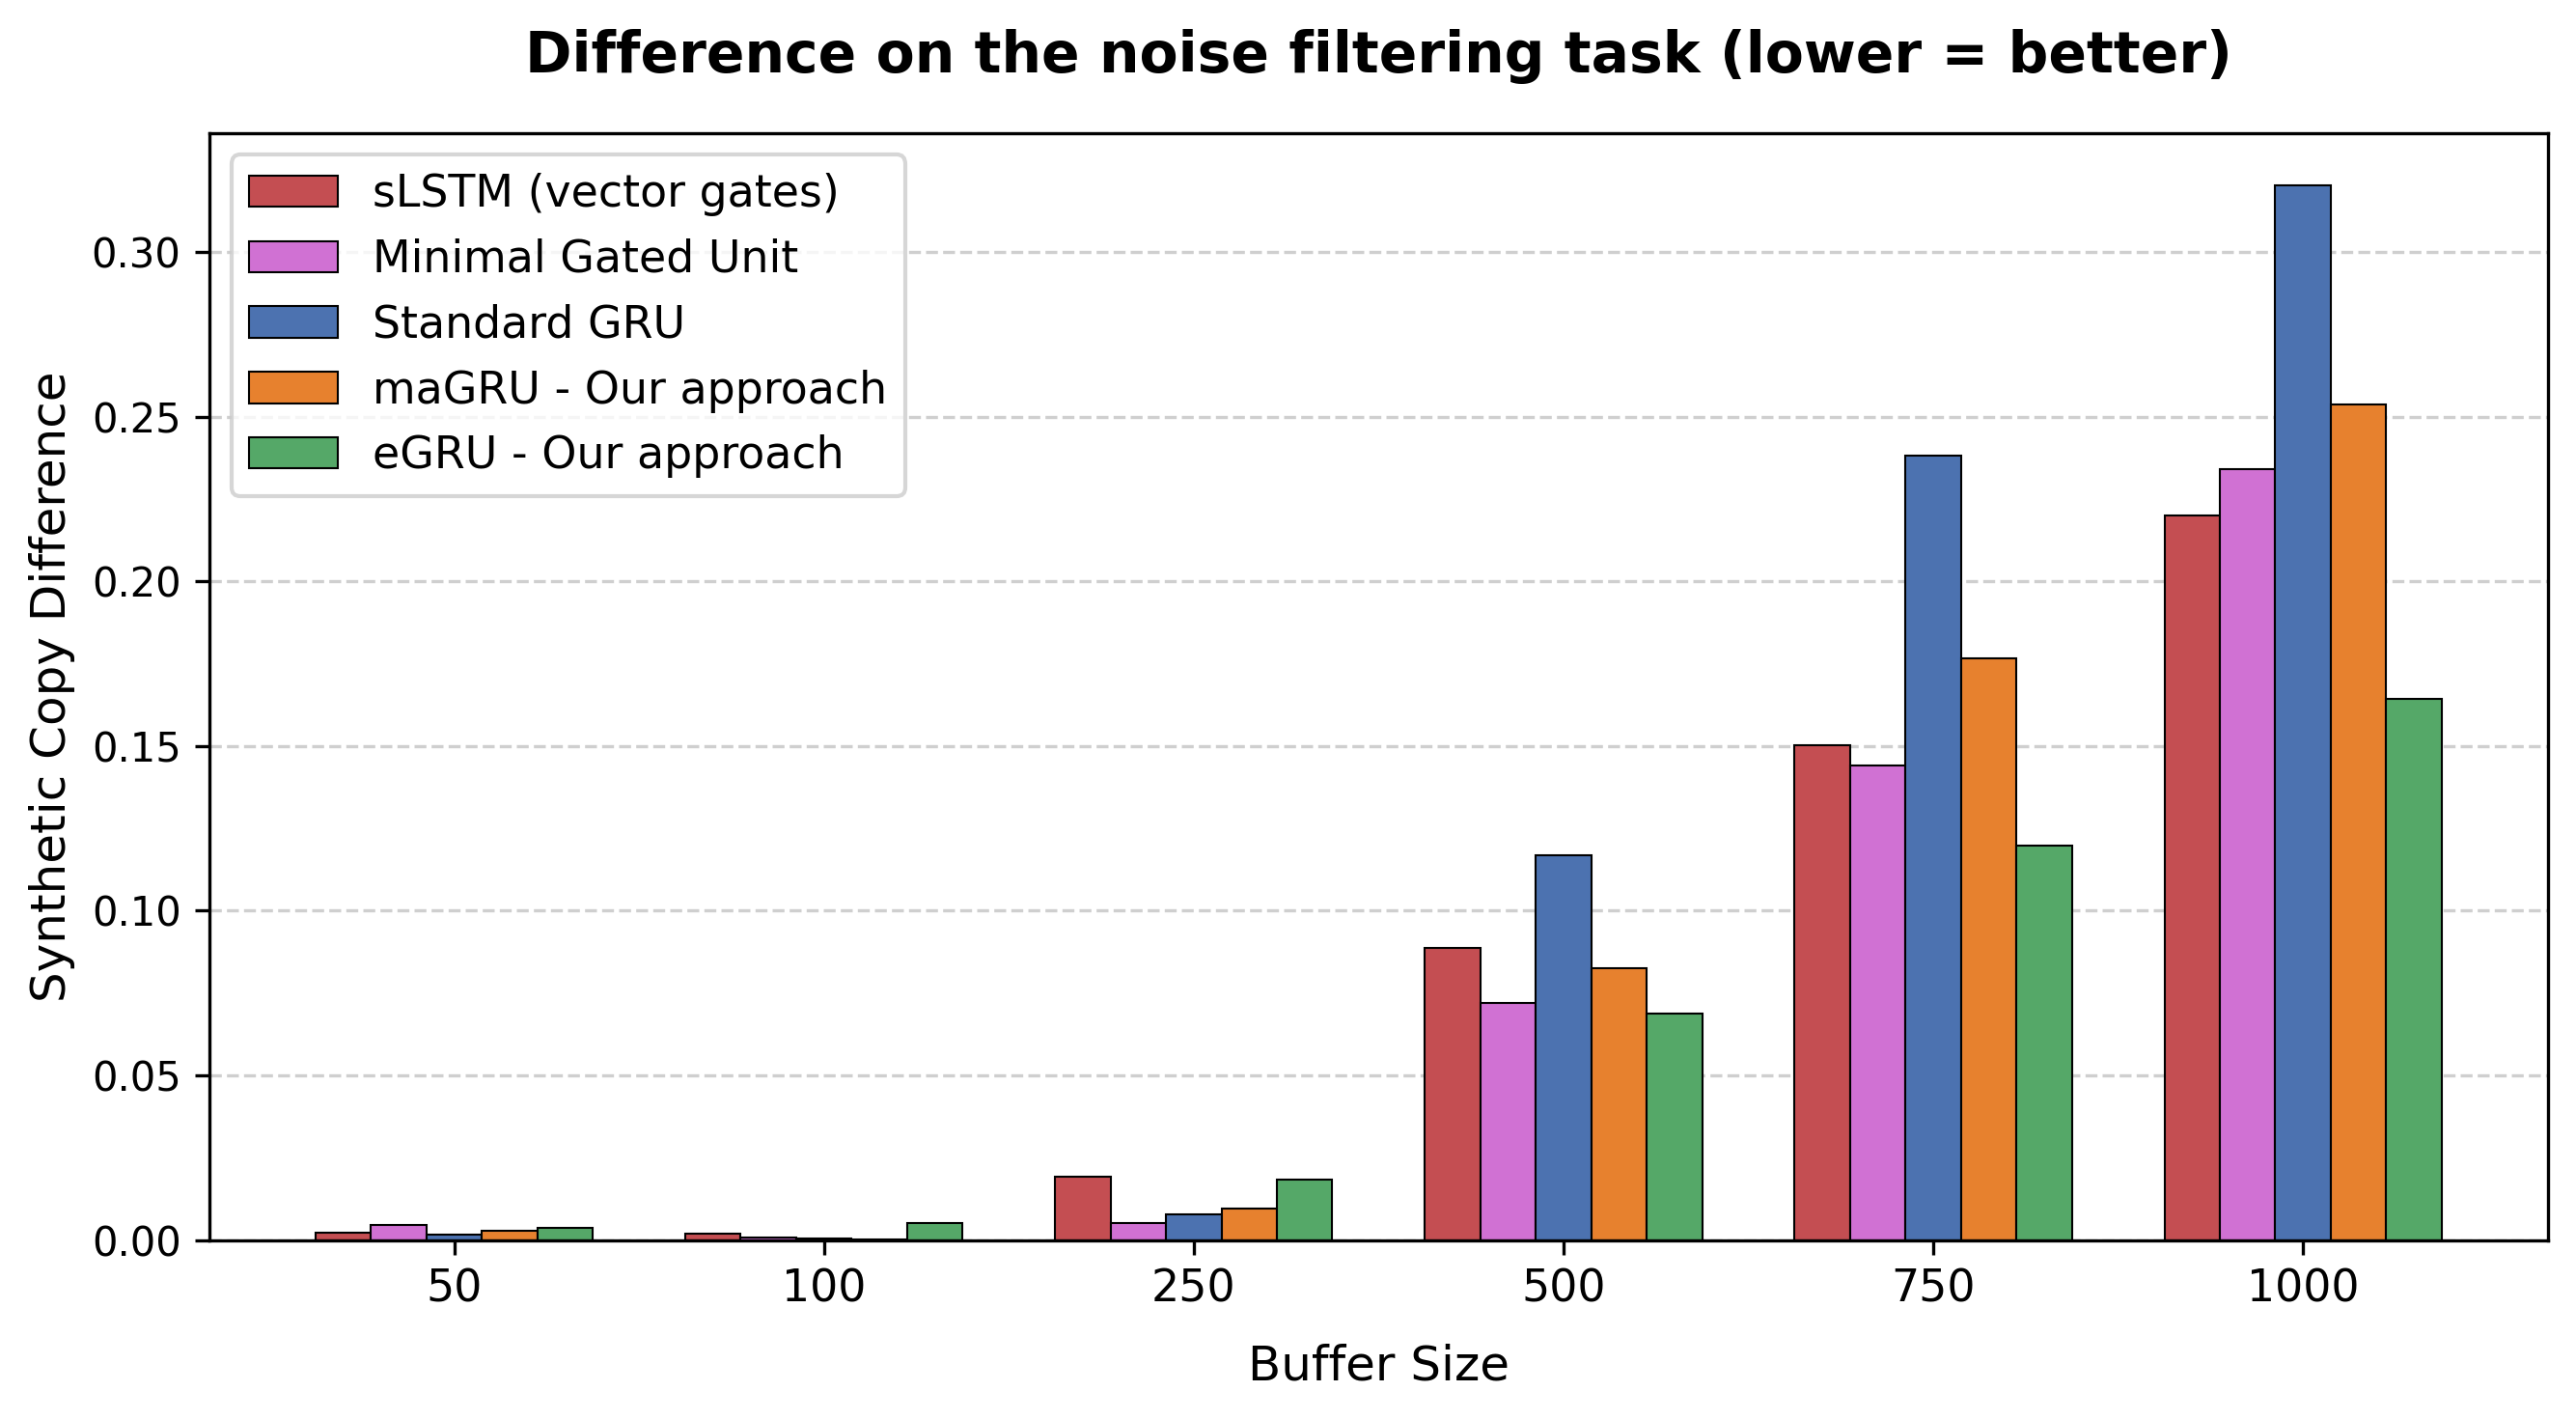

In [7]:
standard_gru = [
    0.0017017327009303735,
    0.0004641089178068508,
    0.007642326901878904,
    0.1168007442709243,
    0.2381497556620305,
    0.32017327269705215,
]

egru = [
    0.0036509901718559242,
    0.005228960499314979,
    0.01840965375350327,
    0.06875000121348565,
    0.11983292313790557,
    0.16435643949426046,
]

magru = [
    0.002815594117498339,
    0.00021658416164319704,
    0.009405940771102905,
    0.08264232821541258,
    0.17673267660164596,
    0.2537128760082887,
]

MGU = [
    0.004610148622737367,
    0.0006806930794500479,
    0.005105198125843659,
    0.07209158548624209,
    0.1439975265524175,
    0.2340037158810266,
]

sLSTM = [
    0.00227272732775997,
    0.001988636393269355,
    0.019318182148378004,
    0.08863636512647975,
    0.15028409524397415,
    0.21988636661659589,
]


import matplotlib.pyplot as plt
import numpy as np

# Data

buffer_sizes = ["50", "100", "250", "500", "750", "1000"]



# Plot setup

x = np.arange(len(buffer_sizes))
width = 0.15

fig, ax = plt.subplots(figsize=(9, 5), dpi=300)


# Create bars

rects0 = ax.bar(
    x - 2 * width,
    sLSTM,
    width,
    label="sLSTM (vector gates)",
    color="#C44E52",
    edgecolor="black",
    linewidth=0.5,
)

rects1 = ax.bar(
    x - width,
    MGU,
    width,
    label="Minimal Gated Unit",
    color="#D071D3",
    edgecolor="black",
    linewidth=0.5,
)

rects2 = ax.bar(
    x,
    standard_gru,
    width,
    label="Standard GRU",
    color="#4C72B0",
    edgecolor="black",
    linewidth=0.5,
)

rects3 = ax.bar(
    x + width,
    magru,
    width,
    label="maGRU - Our approach",
    color="#E7812E",
    edgecolor="black",
    linewidth=0.5,
)

rects4 = ax.bar(
    x + 2 * width,
    egru,
    width,
    label="eGRU - Our approach",
    color="#55A868",
    edgecolor="black",
    linewidth=0.5,
)


# Titles and labels

ax.set_title(
    "Difference on the noise filtering task (lower = better)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)

ax.set_xlabel(
    "Buffer Size",
    fontsize=12,
    fontweight="medium",
    labelpad=8,
)

ax.set_ylabel(
    "Synthetic Copy Difference",
    fontsize=12,
    fontweight="medium",
)

ax.set_xticks(x)
ax.set_xticklabels(buffer_sizes, fontsize=11)


# Aesthetics

ax.legend(fontsize=11, frameon=True)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.6,
)

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()